In [1]:
import pandas as pd
from geostat_isoscapes_tools import geostat_utils as gutils, plot_utils as putils, utils
import matplotlib.pyplot as plt 
import numpy as np
import skgstat as skg
from tqdm import tqdm
from scipy.spatial.distance import pdist
import seaborn as sns
import json
from scipy.stats import pearsonr


sns.set_theme(context='talk',
                  style='ticks',
                  palette='colorblind',
                  rc={'axes.linewidth':1.2,"grid.alpha":0.3,"grid.linestyle":'--'})
plt.close("all") 

## Chen et al. dataset

**[Chen dataset](https://zenodo.org/records/7306199) (download the *.nc* file).**

This dataset is not a direct output from isotope-enabled GCMs. Instead, it has been generated through data fusion and bias correction techniques based on GCM outputs. In other words, post-processing methods were applied to the model outputs to bring the simulations closer to observational data. This dataset is 1870–2017 at a monthly scale.

First, we import useful libraries and read the netCTF4 file with xarray to get a Dataset object. 

In [2]:
fn = '../data/modern/PrecipOxygenIso_mainlandCHINA_1870to2017_v2.nc'

file = utils.load_xarray_datarray(fn)
d18Op = file.d18Op

# make the time dimension a datetime index, starting from 1870-01-01, with monthly frequence so that time 1 becomes 1870-01-31, etc.
time_index = pd.date_range(start='1870-01-31', periods=d18Op.sizes['time'], freq='ME')
d18Op = d18Op.assign_coords(time=time_index)
# transpose so that the order of the dims is lat/lon and not lon/lat (pb with plotting fct and flattening otherwise)
d18Op = d18Op.transpose('time','lat','lon')

### Basic plots

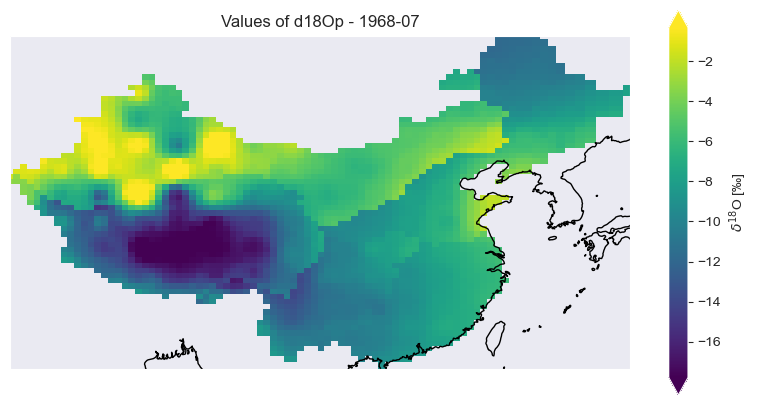

In [ ]:
# Plot with cartopy
da_sel = d18Op.sel(time='1968-07-31') #1775
fig,ax = putils.plot_latlon_platecarree(da_sel,time='1968-07')
# plt.savefig("../output/data_exploration/chen_map1968-07.png",dpi=400)
plt.show()

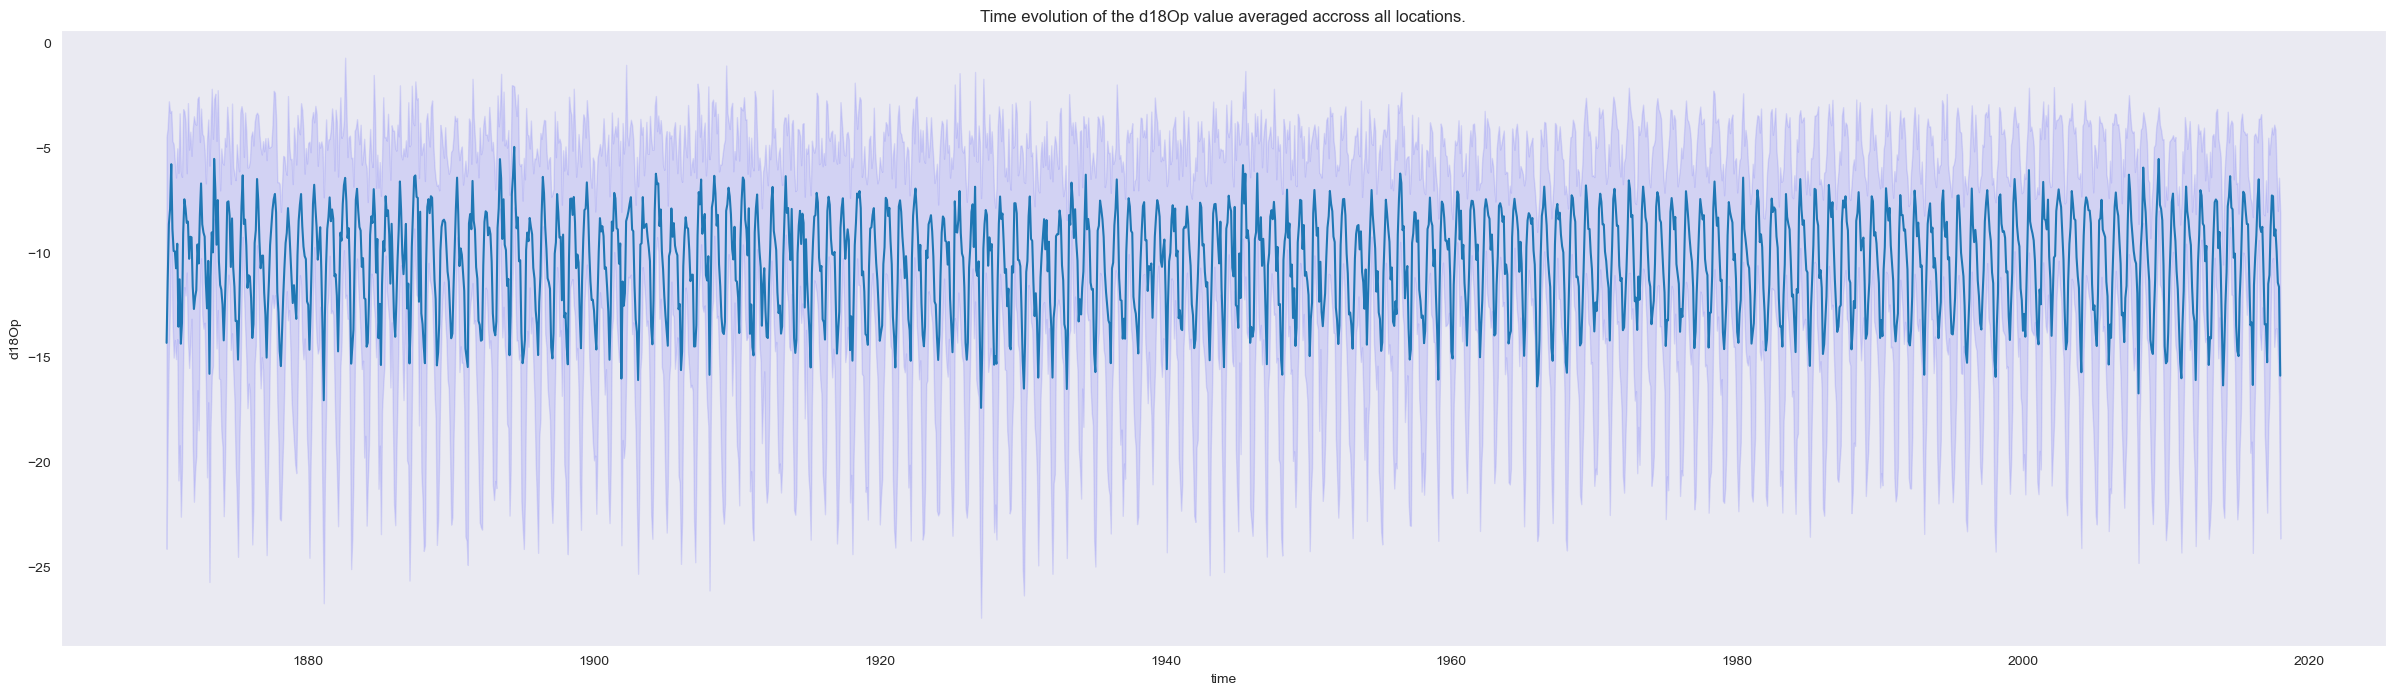

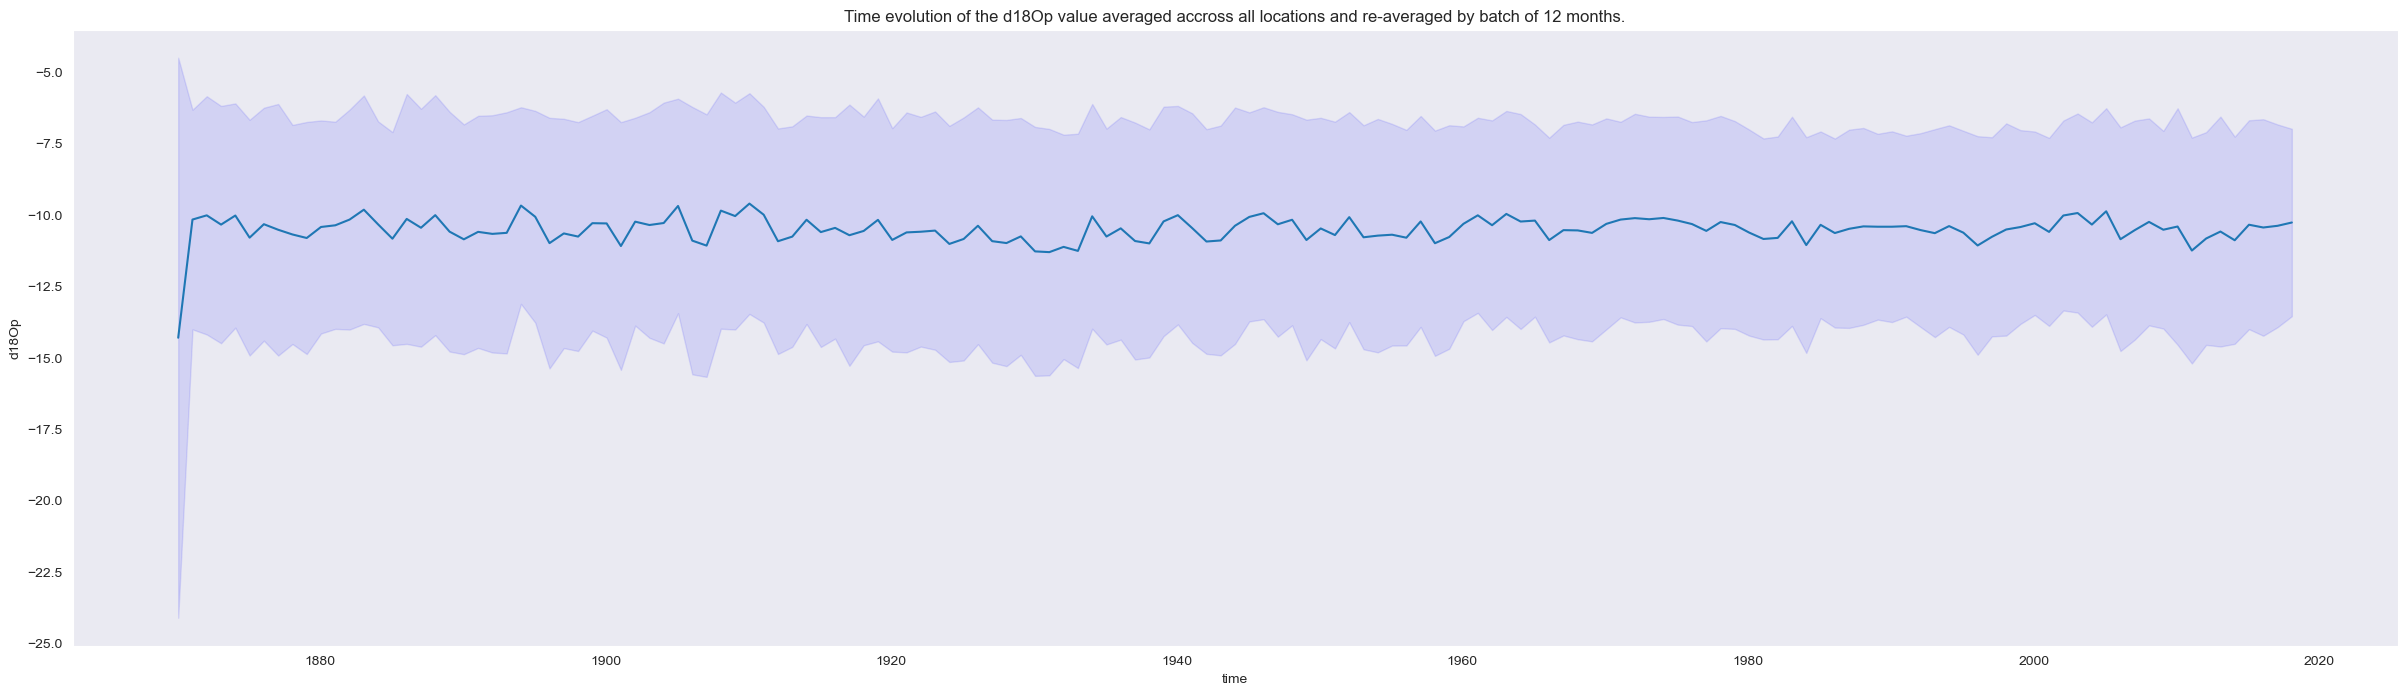

In [4]:
# Mean across all lat/lon with std shown
global_std = d18Op.std(dim=("lat", "lon"))
plt.figure(figsize=(30,8))
global_mean = d18Op.mean(dim=("lat", "lon"))
global_mean.plot.line(x="time")
plt.fill_between(global_mean.time.values, 
                 (global_mean - global_std).values, 
                 (global_mean + global_std).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations.')
plt.show()

# Mean across all lat/lon re-averaged by batch of 12 months
plt.figure(figsize=(30,8))

global_mean_12m = d18Op.resample(time='12ME').mean().mean(dim=("lat", "lon"))
global_std_12m = d18Op.resample(time='12ME').mean().std(dim=("lat", "lon"))
global_mean_12m.plot.line(x="time")
plt.fill_between(global_mean_12m.time.values, 
                 (global_mean_12m - global_std_12m).values, 
                 (global_mean_12m + global_std_12m).values, 
                 color='b', alpha=0.1, label='±1 std dev')
plt.title('Time evolution of the d18Op value averaged accross all locations and re-averaged by batch of 12 months.')
plt.show()

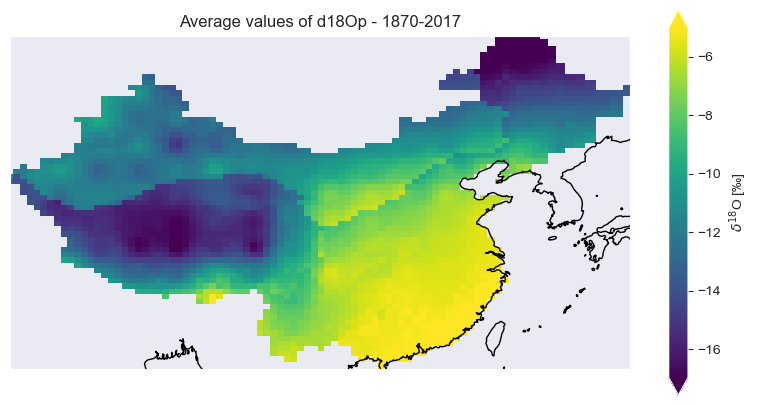

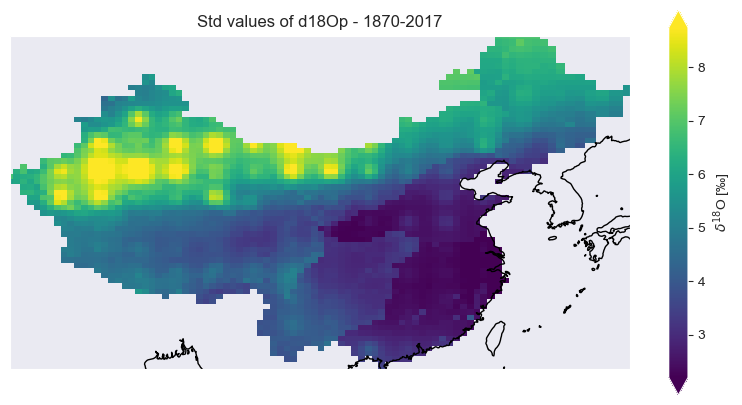

In [ ]:
# mean and variance accross time
mean_d18Op = d18Op.transpose('time','lat','lon').mean(dim="time")
std_d18Op = d18Op.transpose('time','lat','lon').std(dim="time")   

fig, ax = putils.plot_latlon_platecarree(mean_d18Op, time='1870-2017', title="Average values of d18Op")
plt.show()

fig,ax=putils.plot_latlon_platecarree(std_d18Op,time='1870-2017', title='Std values of d18Op')
plt.show()


High varibaility in NW region was explained by authors in the dataset's paper :

*"For NW, the variability of δ18Op simulations is also large. This is because, on the one hand, the sparse coverage of stations coupled with complex topography over northwest China cannot well represent the full range of precipitation isotope conditions. This can lead to biases in the distribution of observations. On the other hand, the arid northwest region is one of the most sensitive regions to climate change due to its fragile ecosystem, which affects sub-cloud evaporation and local moisture re-cycling, leading to the large uncertainty in isotope simulation between different iGCMs23,81."*

### Variogram for a given time point (month)

In [6]:
time = '2006-12-31' 

#### Experimental Variogram (gstat, Euclidean distances) 

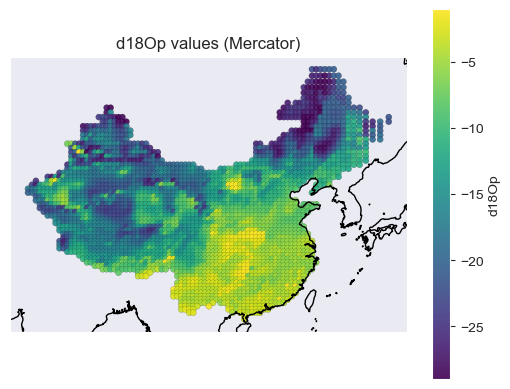

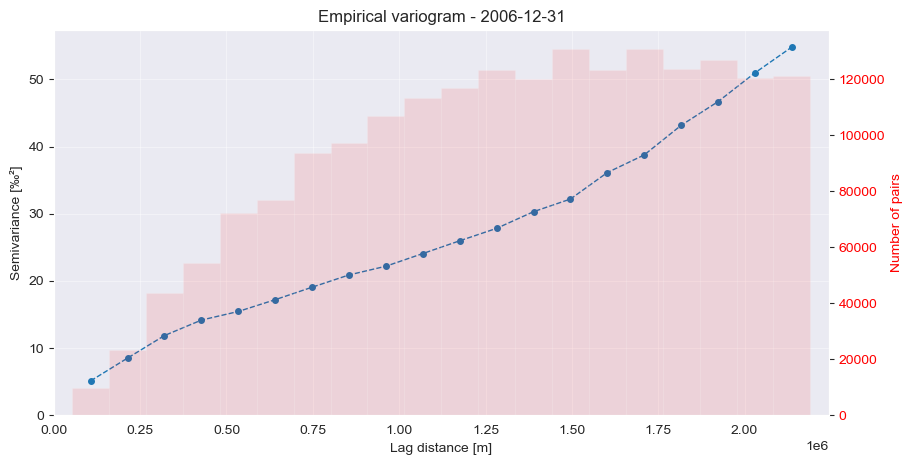

In [7]:
# Prepare data
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")
# Plot projected data
fig, ax = putils.plot_projected_data(coords_proj, vals_s, projection_str='Mercator')
plt.show()

# Compute Variogram
V = skg.Variogram(coords_proj, vals_s, n_lags=20, maxlag='median', model='spherical', use_nugget=True, normalize=False)

fig,ax = putils.plot_variogram_from_bins_and_gamma(centers = V.bins,
                                                   gamma = V.experimental,
                                                   time = time,
                                                   counts = V.bin_count,
                                                   min_pairs=30,
                                                   plot_model=False,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model) #type:ignore

#### Experimental Variogram of the **residuals** after trend removal (gstat, Euclidean distances)

Var(original) = 53.63039924335896  Var(residual) = 19.56378951852522


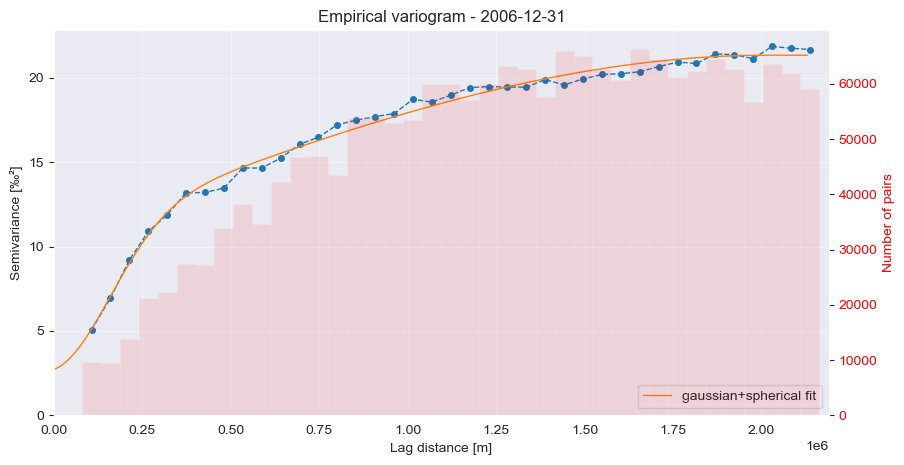

In [8]:
coords, vals_s = gutils.get_projected_coords_and_vals(d18Op,time=time,epsg="EPSG:3857")

resid,lr = gutils.detrend_data_plane(coords,vals_s)

# quick check: variance reduction after detrend
print("Var(original) =", np.var(vals_s), " Var(residual) =", np.var(resid))

# sensible maxlag: e.g. half the maximum pairwise distance or 1/3
dmax = pdist(coords).max()
maxlag = dmax *0.6

# build variogram on residuals, with metric distances, no normalization
V = skg.Variogram(coords, resid,
                  n_lags=40,
                  maxlag='median',
                  model='gaussian+spherical',
                  use_nugget=True,
                  normalize=False,
                  verbose=True)

fig, ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                    V.experimental,
                                                    time,
                                                    V.bin_count,
                                                    min_pairs=30,
                                                    plot_model=True,
                                                    model_name=V._model_name,
                                                    model_fct = V.fitted_model,
                                                    ) #type:ignore


#### Experimental Variograms using geodesic distances

Max pairwise distance: 4960.0 km


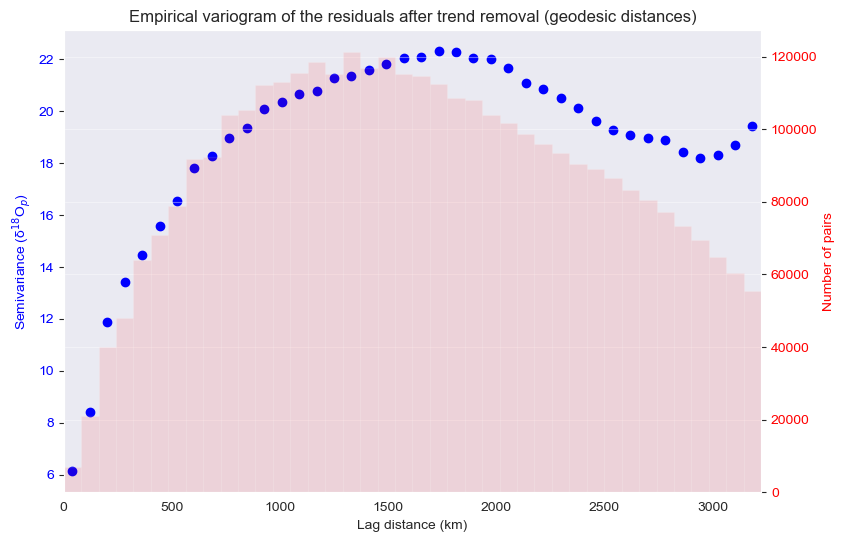

In [9]:
da_slice = d18Op.sel(time=time) 

# Get lon, lat, and values (1D)
lon2d, lat2d = np.meshgrid(da_slice['lon'].values, da_slice['lat'].values)
values = da_slice.values
mask = ~np.isnan(values)
lons = lon2d[mask]
lats = lat2d[mask]
vals = values[mask]
lonlat = np.column_stack((lons, lats))

# remove linear trend 
X = np.column_stack((lons, lats))
residuals,params = gutils.detrend_data_plane(X,vals)

# Compute distances (meters)
distances = gutils.geodesic_condensed_distances(lonlat)
print(f"Max pairwise distance: {distances.max()/1000:.1f} km")

# Compute semivariances
# pdist (to compute on each pair) with a custom lambda for squared difference (->computes squared diff of each pair)
semivars = pdist(residuals.reshape(-1, 1), lambda u, v: 0.5 * (u - v) ** 2)

# Bin distances into lag classes
n_bins = 40
maxlag = distances.max() * 0.65 
bins = np.linspace(0, maxlag, n_bins + 1)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Assign each distance to a bin
bin_idx = np.digitize(distances, bins) - 1

# Compute mean semivariance per bin
gamma = np.full(n_bins, np.nan)
counts = np.zeros(n_bins, dtype=int)

for k in range(n_bins):
    sel = bin_idx == k
    counts[k] = np.sum(sel)
    if counts[k] > 0:
        gamma[k] = np.mean(semivars[sel])

# Mask unreliable bins (few pairs)
min_pairs = 30  # threshold of minimum pairs per bin
reliable = counts >= min_pairs

fig, ax1 = plt.subplots(figsize=(9, 6))

# Plot semivariance
ax1.plot(bin_centers[reliable]/1000, gamma[reliable], 'o', color='blue', label='Empirical γ(h)')
ax1.set_xlabel('Lag distance (km)')
ax1.set_ylabel('Semivariance (δ$^{18}$O$_p$)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Overlay pair counts
ax2 = ax1.twinx()
ax2.bar(bin_centers/1000, counts, width=(bin_centers[1]-bin_centers[0])/1000,
        color='red', alpha=0.1, label='Pair counts')
ax2.set_ylabel('Number of pairs', color='red')
ax2.tick_params(axis='y', labelcolor='red')
plt.xlim(0, maxlag/1000)
plt.title('Empirical variogram of the residuals after trend removal (geodesic distances)')
plt.grid(True, alpha=0.4)
plt.show()

#### *drafts - variograms computations*

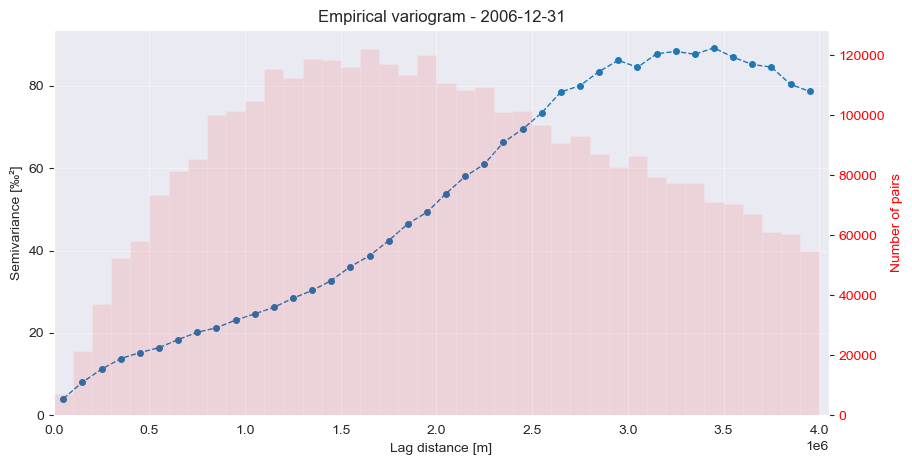

In [10]:
coord_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

centers, gamma, counts = gutils.variogram_gstools(coords_proj, vals_s, n_bins=40, maxlag=4000000)

# plot
fig, ax = putils.plot_variogram_from_bins_and_gamma(centers,gamma,time,counts,min_pairs=30)
plt.show()

In [11]:
# prepare A (meshgrid) and B (to_dataframe) again
da_slice = d18Op.sel(time='1969-12-31')
lons = da_slice['lon'].values
lats = da_slice['lat'].values
lon_grid, lat_grid = np.meshgrid(lons, lats,indexing='ij')   # <- indexing='ij' to preserve order
coords = np.column_stack([lon_grid.ravel(order='C'), lat_grid.ravel(order='C')])
values = da_slice.values.ravel(order='C')
mask = ~np.isnan(values)
coords_A = coords[mask]
vals_A = values[mask]

df = d18Op.to_dataframe(name='d18Op').reset_index()
df = df[(df['time'].dt.year==1969) & (df['time'].dt.month==12) & (df['time'].dt.day==31)].dropna(subset=['d18Op']).copy()
coords_B = df[['lon','lat']].values
vals_B = df['d18Op'].values

print('counts A,B:', coords_A.shape[0], coords_B.shape[0])
print('da_slice.shape, coords grid shape:', da_slice.shape, lon_grid.shape)

# compare lon/lat pairs before projection
setA = set(map(tuple, np.round(coords_A, 6)))
setB = set(map(tuple, np.round(coords_B, 6)))
print('n only in A:', len(setA - setB))
print('n only in B:', len(setB - setA))
# show some examples
print('examples only in A (first 5):', list(setA - setB)[:5])
print('examples only in B (first 5):', list(setB - setA)[:5])

# check lon ranges / ordering
print('lons range (grid):', lons.min(), lons.max())
print('lons range (df):', df['lon'].min(), df['lon'].max())
print('first/last lats:', lats[:3], lats[-3:])
print('unique lat ordering in df head/tail:', df['lat'].unique()[:3], df['lat'].unique()[-3:])

counts A,B: 2779 2779
da_slice.shape, coords grid shape: (64, 87) (87, 64)
n only in A: 1171
n only in B: 1171
examples only in A (first 5): [(np.float64(97.427643), np.float64(45.46204)), (np.float64(96.111839), np.float64(48.018631)), (np.float64(109.927803), np.float64(51.828369)), (np.float64(101.375), np.float64(44.446171)), (np.float64(106.638199), np.float64(53.101101))]
examples only in B (first 5): [(np.float64(123.395401), np.float64(50.127079)), (np.float64(75.717072), np.float64(37.85358)), (np.float64(120.564003), np.float64(51.828369)), (np.float64(87.559212), np.float64(29.23386)), (np.float64(117.855904), np.float64(28.21978))]
lons range (grid): 73.7431869506836 134.0970001220703
lons range (df): 73.7431869506836 134.0970001220703
first/last lats: [53.10110092 52.44433975 51.82836914] [21.62822914 21.12118912 20.61413956]
unique lat ordering in df head/tail: [53.10110092 52.44433975 51.82836914] [21.62822914 21.12118912 20.61413956]


[[13498167.69893585  7001720.79383137]
 [13576224.34292035  7001720.79383137]
 [13655517.56816245  7001720.79383137]
 ...
 [12530199.74754369  2466947.79836194]
 [12237107.05838606  2406334.97568083]
 [12237107.05838606  2345927.87489557]]


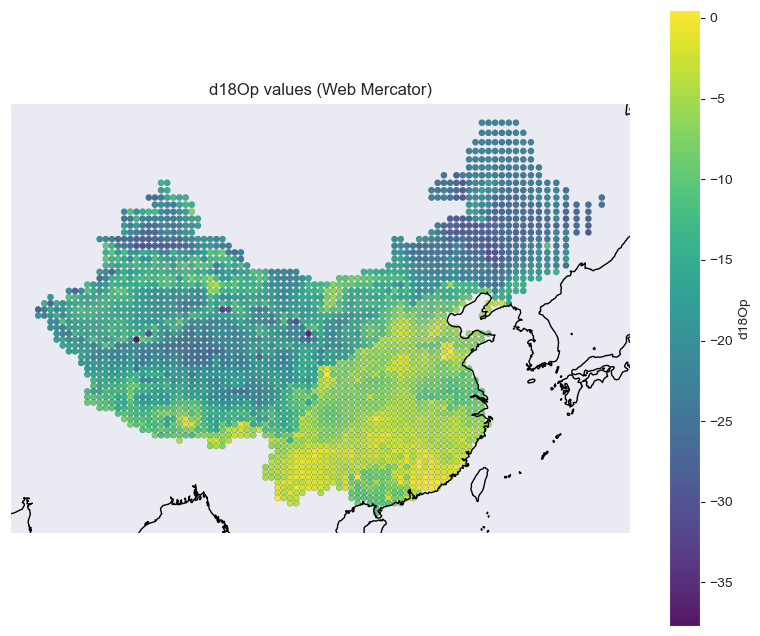

In [12]:
import cartopy.crs as ccrs
from pyproj import Transformer

# flatten with xarray (no meshgrid/ravel headaches)
stacked = da_slice.stack(point=('lat','lon')).dropna('point')   # or ('lon','lat') to match your desired order
lons_s = stacked['lon'].values
lats_s = stacked['lat'].values
vals_s = stacked.values

# project vectorized
transformer = Transformer.from_crs("EPSG:4326","EPSG:3857", always_xy=True)
xs, ys = transformer.transform(lons_s, lats_s)
coords_proj = np.column_stack([xs, ys])
print(coords_proj)

# fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.PlateCarree()})
# sc = ax.scatter(lons_s, lats_s, c=vals_s, s=20, cmap="viridis", transform=ccrs.PlateCarree(), alpha=0.9, edgecolor="k", linewidth=0.1)
# ax.coastlines(resolution="50m")
# ax.set_title("d18Op values (lon/lat)")
# plt.colorbar(sc, ax=ax, label="d18Op")
# plt.show()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={"projection": ccrs.Mercator()})
sc = ax.scatter(xs, ys, c=vals_s, s=20, cmap="viridis", transform=ccrs.Mercator(), alpha=0.9, edgecolor="k", linewidth=0.1)
ax.coastlines(resolution="50m")
ax.set_title("d18Op values (Web Mercator)")
plt.colorbar(sc, ax=ax, label="d18Op")
plt.show()


#### Directional variograms (gstat)

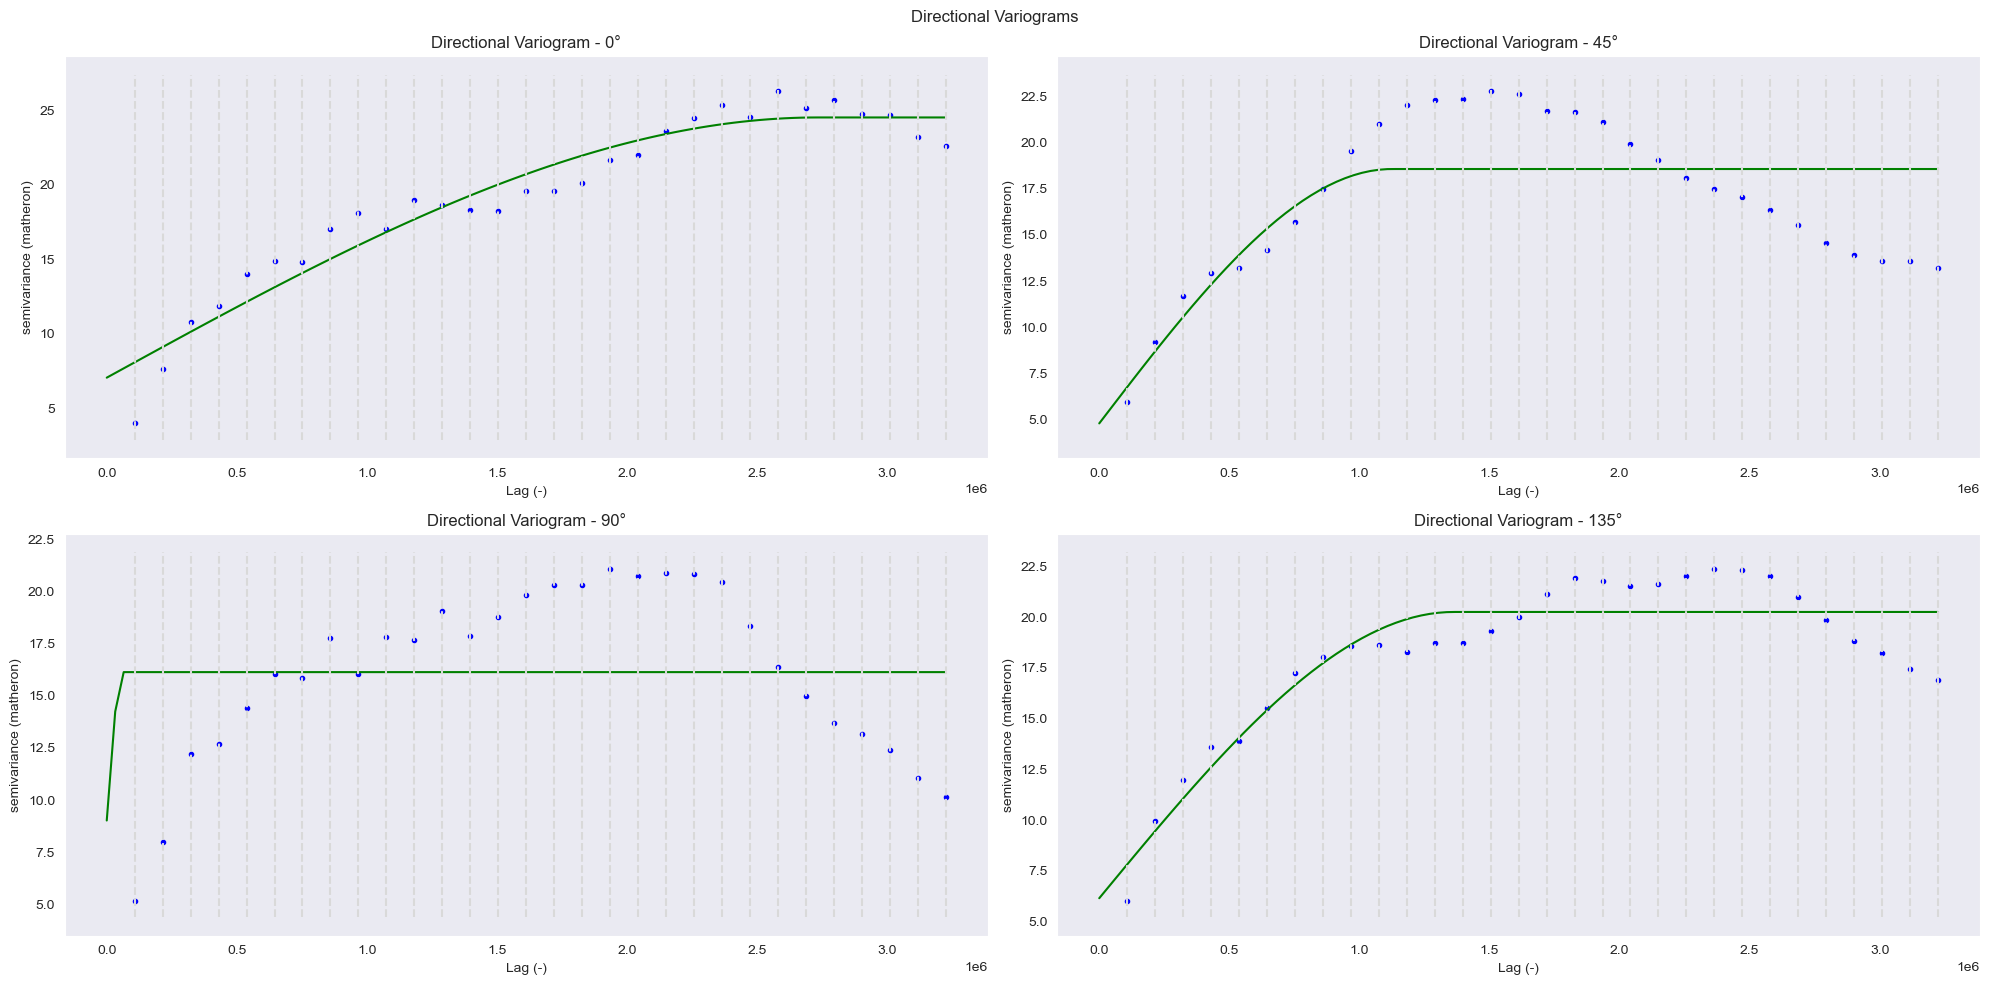

Range in direction 0°: 17.43939884403119
Range in direction 45°: 13.792435189966538
Range in direction 90°: 7.11890910534521
Range in direction 135°: 14.112149723555621
Anisotropy Ratio: 2.449729106800489
Anisotropy Direction: 0°


In [13]:
coords_proj, vals_s = gutils.get_projected_coords_and_vals(d18Op, time=time, epsg="EPSG:3857")

resid, params = gutils.detrend_data_plane(coords_proj,vals_s)

# # show the map of data and residuals again 
# fig, ax = putils.plot_projected_data(coords_proj,vals_s,'Mercator')
# plt.show()
# fig,ax = putils.plot_projected_data(coord_proj,resid,'Mercator')
# plt.show()

# Compute directional variogram
directions = [0,45,90,135]
ranges = []
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
axes = axes.flatten()
for i, direction in enumerate(directions):
    V_dir = skg.DirectionalVariogram(coords_proj,resid,n_lags=30,maxlag=maxlag,
                                     model='spherical',use_nugget=True,normalize=False,
                                     azimuth=direction,tolerance = 22.5 )
    ranges.append(V_dir.parameters[1])
    V_dir.plot(axes=axes[i], show=False, grid=True)
    axes[i].set_title(f'Directional Variogram - {direction}°')
plt.suptitle('Directional Variograms')
plt.tight_layout()
plt.show()

for dir, r in zip(directions, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {directions[max_range_index]}°')


### Global variograms

In [ ]:
# convert the xarray into dataframe
df = d18Op.to_dataframe(name='d18Op').reset_index().dropna()
df = gutils.add_external_variables_to_lonlat_df(df,variables=['ele'])
# df = df[( df['time'].dt.month.isin([10,11,12,1,2,3,4]))] # Moonsoon = May to September

df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")

bins, bin_count, gammas = None, None, []
for t, g in tqdm(df.groupby('time')):
    if g['d18Op'].notna().sum() < 30:
        continue
    try:
        b, g_exp, bin_count,_,_ = gutils.variogram_with_gstat(g,quantity='d18Op',trend='multiple_linear_lat_ele',maxlag='median',return_Variogram_object=False,verbose=False) # type: ignore
        # at each time step the locations stay the same, so bins and bin counts are constant
        if bins is None:
            bins = b
            bin_count = bin_count
        # append the semivariances to the list
        gammas.append(g_exp)
    except Exception as e:
        print(f"Skipped {t}: {e}")

-> Adding external variables ['ele'].
   > elevation data will be taken from file ../data/elevation/ETOPO_2022_v1_60s_N90W180_surface.nc


 86%|████████▌ | 1520/1776 [30:12<05:38,  1.32s/it]

**Motivation for computing each variogram separetly**:

There is the same number of pairs at each timestep. Hence, if the variogram is computed for each timestep separately and then the mean is taken, it is equivalent to computing the variogram directly with all pairs from all timesteps (which would require an immense amount of memory). 

This is due to the fact that the value of the variogram at one bin is the mean semivariance at lag h, and a sum of means is the mean of the sum only if each sum has the same number of elements.

In [ ]:
mean_gamma = np.nanmedian(np.vstack(gammas), axis=0)
mean_df = pd.DataFrame({'lag': bins, 'gamma': mean_gamma,'bin_count':bin_count})
fig, ax = putils.plot_variogram_from_bins_and_gamma(mean_df['lag'],mean_df['gamma'],time='1870-2017',counts = bin_count,save_name='../output/variograms/alltimes_multiple_linear_ele_lat_maxlag2e6m_variogram_df_chen.png') #type:ignore
plt.show()

ValueError: need at least one array to concatenate

In [ ]:
mean_df.to_csv('../output/variograms/alltimes_multiple_linear_ele_lat_maxlag2e6m_variogram_df_chen.csv')

## iTrace dataset

This dataset is the output of the iTrace simulation (Community Land Model from iCESM).

We download the files at this [link](https://gdex.ucar.edu/datasets/d651022/dataaccess/#), with the naming conventions explained [here](https://yefee.github.io/iTRACE/).

The quantity $\delta^{18}\text{O}$ is not directly available, we must compute it from the total water trace (H2OTR, in m/s) data and the heavy oxygen water precipitation data (H218O, in m/s).


>The name of the files is consituted of (from left to right)
   >
   > 1. `b.e13.Bi1850C5`: the machine used for the iTrace simulation
   >
   > 1. `f19_g16`: the spatial resolution of the simulation (about 1.9° lat x 2.5° lon).
   >
   > 1. `xxka`: the temporal slice of the simulation (see the documentation for precise info)
   >
   > 1. `ice_ghg_orb_wtr.0x` or any subset of it : the forcings applied during the simulation.
   >
   > 1. `clm2`: the Community Land Model version 2 (cam2 for atmoshperic model...)
   >
   > 1. the name after all is the variable name.

##### Detailed procedure of the delta 18O computation from itrace files (now wrapped in a more sophisticated function, including snowfall...)

In [2]:
fn_itrace_H218O = '/media/luluxette/T7_Shield/pdm/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H218O.800001-899912.nc'
fn_itrace_H2OTR = '/media/luluxette/T7_Shield/pdm/iTrace/b.e13.Bi1850C5.f19_g16.12ka.itrace.ice_ghg_orb_wtr.05.clm2.h0.RAIN_H2OTR.800001-899912.nc'

file_H218O = utils.load_xarray_datarray(fn_itrace_H218O)
file_H2OTR = utils.load_xarray_datarray(fn_itrace_H2OTR)

# print(file_H218O.info())
# print(file_H2OTR.info())

h218o = file_H218O.RAIN_H218O
h2o = file_H2OTR.RAIN_H2OTR

In [3]:
print('This dataset covers ',len(h218o.time)/12, ' years at monthly resolution.')

This dataset covers  1000.0  years at monthly resolution.


The fluxes (in mm/s) are actually already corrected for the molar mass and VSMOW standard by the iCESM model (see this [forum](https://bb.cgd.ucar.edu/cesm/threads/how-can-i-use-the-output-variables-of-icesm-to-generate-%CE%B418o-in-atmospheric-precipitation.10990/)). 

Hence, $R_{^{18}O} = \frac{n_{^{18}O}}{n_{^{16}O}} = \frac{f_{^{16}O}}{f_{^{18}O}} $

In [4]:
# ---- No need of this correction --- 
# Divide the mm/s by the molar mass to get molar-mass corrected fluxes
# M16 = 18.01056468403e-3  # kg/mol
# M18 = 20.01481106446e-3
# R_vsmow = 0.0020052
# mol_ratio = (h218o / h2o) * (M16 / M18)
# delta18 = ( mol_ratio / R_vsmow - 1.0) * 1000.0

# Compute delta 18 O (per thousand)
delta18 = ( h218o/h2o - 1.0) * 1000.0
delta18 = delta18.where((h2o > 1e-12)&(delta18 < 100))  # avoid div by near-0 precip values and positive outliers (delta18 should be mostly negative and small -20/+20)

The time dimension is defined in days after a random date, we want to chenge this to something more meaningful. According to the [table](https://docs.google.com/spreadsheets/d/10WhscwRmVM3FJIPymjcbT6aGKRisAkQ-dnpmxr7Psso/edit?gid=0#gid=0)  linked in [documentation](https://yefee.github.io/iTRACE/), each itrace file contains exactly 1000 years of data at monthly resolution. Thus, we will simply set the time as a number between 1 and 12000, indicating the number of months after the last month of 12kyrBP. Hence, time=1 will refer to the first month of 11999yrBP, etc.

In [5]:
time_ = range(0,len(delta18.time))
delta18 = delta18.assign_coords(time=('time',time_))
delta18 = delta18.assign_coords(time = delta18.time.assign_attrs(units="months since beginning of 12 kyr BP"))

delta18.time

<xarray.DataArray 'time' (time: 12000)> Size: 96kB
array([    0,     1,     2, ..., 11997, 11998, 11999], shape=(12000,))
Coordinates:
  * time     (time) int64 96kB 0 1 2 3 4 5 ... 11995 11996 11997 11998 11999
Attributes:
    units:    months since beginning of 12 kyr BP

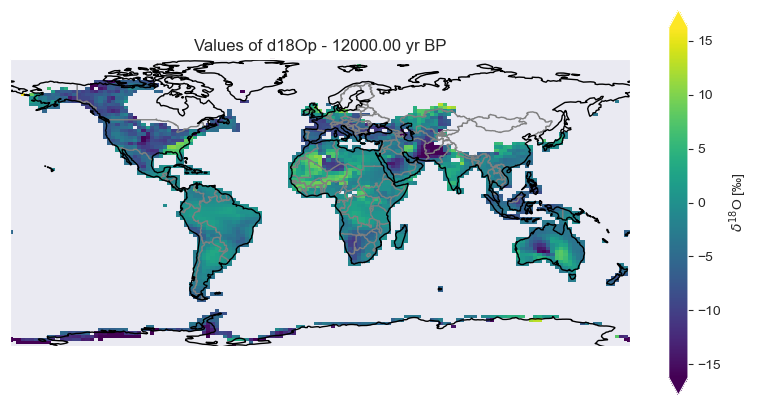

In [ ]:
months_after_start = delta18.time.values[0] 
to_plot = delta18.sel(time=months_after_start)
# map of the mean d18O 
fig,ax = putils.plot_latlon_platecarree(to_plot,time=f'{utils.get_yrBP_from_itrace_time(months_after_start,start_year=12000) :.2f} yr BP', countries_borders=True)
# plt.savefig('../output/data_exploration/itrace_map_example.png',dpi=500)
plt.show()  

We can also mask the region of interest using a shapefile.

In [7]:
import geopandas as gpd
fn_countries = "../data/shapefiles/ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp"
world = gpd.read_file(fn_countries)

In [8]:
countries = ('countries',world.loc[world['CONTINENT'].isin(['Europe','Asia']),'NAME'].to_list())
region_da = utils.mask_regions_shape(delta18,regions=countries)
# this function will be directly applied in the preprocessing of itrace data.

##### Load a 1000yr time slice of itrace (clean fct)

We wrapped up the entire preprocessing of raw itrace files in the function *get_preprocessed_itrace_data*.

In [ ]:
regions = None #['China']
sim_start_yr = 19000 # file for 19ka to 18ka is named '20ka' in itrace simulation outputs (see their roadmap https://docs.google.com/spreadsheets/d/10WhscwRmVM3FJIPymjcbT6aGKRisAkQ-dnpmxr7Psso/edit?gid=0#gid=0)
itrace_ds = gutils.get_preprocessed_itrace_data(
    true_kyr = 20,
    data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',
    sim_prefix = 'b.e13.Bi1850C5.f19_g16',
    sim_suffix ='100001-199912', #12:'800001-899912', #16:'400001-499912', #20 :'100001-199912',
    sim_forcings='ice_ghg_orb_wtr',
    sim_kyr= 20,
    sim_num='01',
    sim_model='clm2.h0',
    res=12*200,
    P = True,
    buffer_km=0,
    format = 'xr',
    regions=regions,
    verbose=True
    )


loading itrace files
This dataset contains  12000  time steps.
   bins of width=2400 months (200 years)
  Loading files for total precipitation info
   rain file info : {'long_name': 'atmospheric rain', 'units': 'mm/s', 'cell_methods': 'time: mean'}


In [5]:
time = itrace_ds.d18Op.time.values[0]
itrace_ds.time

<xarray.DataArray 'time' (time: 5)> Size: 40B
array([   0., 2400., 4800., 7200., 9600.])
Coordinates:
  * time     (time) float64 40B 0.0 2.4e+03 4.8e+03 7.2e+03 9.6e+03

Prepare the data and external variables to use for fitting a trend model (used for variography)

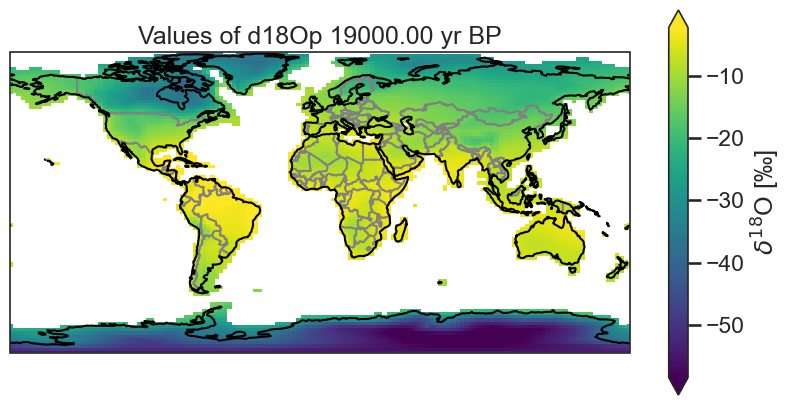

In [ ]:
fig,ax = putils.plot_latlon_platecarree(itrace_ds.sel(time=time).d18Op,time=f'{utils.get_yrBP_from_itrace_time(time, start_year=sim_start_yr):.2f} yr BP',countries_borders=True) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
plt.show() 

df=itrace_ds.sel(time=time).to_dataframe().reset_index().dropna(subset=['d18Op','P']) # type:ignore

df['x'], df['y'] = gutils.project_coords(df['lon'].values, df['lat'].values, epsg="EPSG:3857")

df = gutils.add_external_variables_to_lonlat_df(df,variables=['ele','D'])

> We start by computing a first variogram on a single isoscape (one time-step). 

> Since the dataset contains lots of missing values for some isoscapes, we make sure to choose a time step at which there is no missing value in China. \
> This way, we can extract the bins of the variogram and consider them as reference bins. \
> We will use these reference bins to make variograms for all time steps (all isoscapes), in order to be able to aggregate the results per bin.
> 


##### Variogram for a 1000yr time step

trend to model : multiple_linear_latabs_latReLU_ele_D
-> detrending with multiple linear regression, R2 is 0.886 detailed metrics are :
 (        name      beta     std_error        p_value
0  intercept -0.483993  4.548282e-03   0.000000e+00
1      |lat|  0.103363  3.994580e-03  2.059588e-133
2    latReLU -0.004286  1.265440e-04  3.483538e-213
3        ele -0.000002  2.231311e-07   6.631982e-18
4          D  4.958609  2.447521e-01   1.241264e-85,         name       vif  partial r2
0        ele  1.414214    0.276955
1          D  1.200253    0.024514
2   latblock  1.105740    0.797634
3  intercept       NaN         NaN)


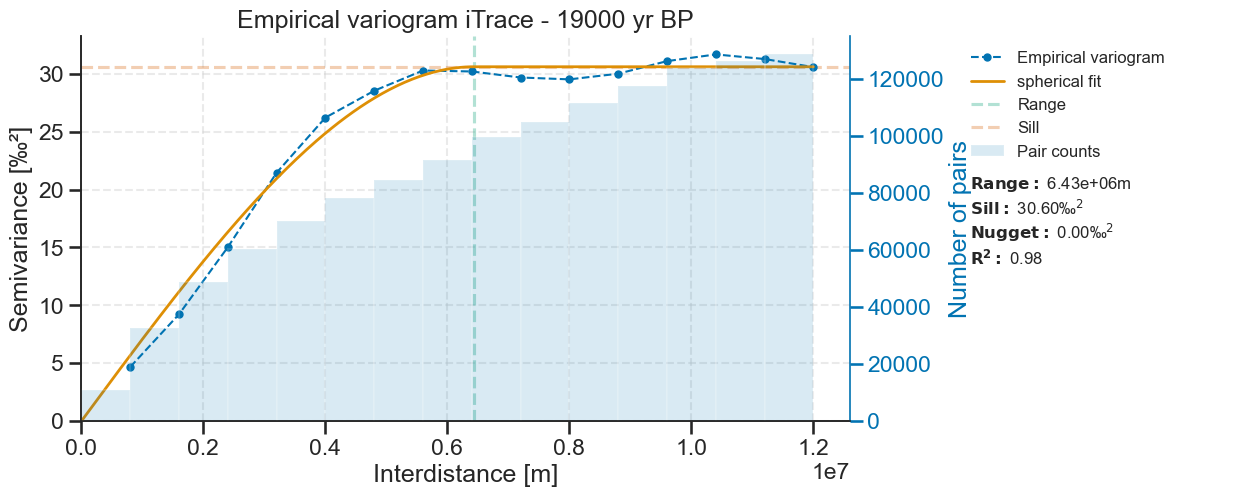

In [12]:
maxlag = 12e6
nlags = 15
V,results = gutils.variogram_with_gstat(df,
                                quantity='d18Op',
                                trend='multiple_linear_latabs_latReLU_ele_D',
                                maxlag=maxlag,
                                nlags=nlags,
                                return_Variogram_object=True,
                                model='spherical'
                                )
ref_bins = V.bins
parameters_dict= gutils.get_gstatvario_params_dict(V.parameters)

fig,ax = putils.plot_variogram_from_bins_and_gamma(V.bins,
                                                   V.experimental,
                                                   f'iTrace - {sim_start_yr} yr BP',
                                                   V.bin_count,
                                                   plot_model=True,
                                                   model_name=V._model_name,
                                                   model_fct=V.fitted_model,
                                                   model_params= parameters_dict
                                                   ) #type:ignore
plt.show()

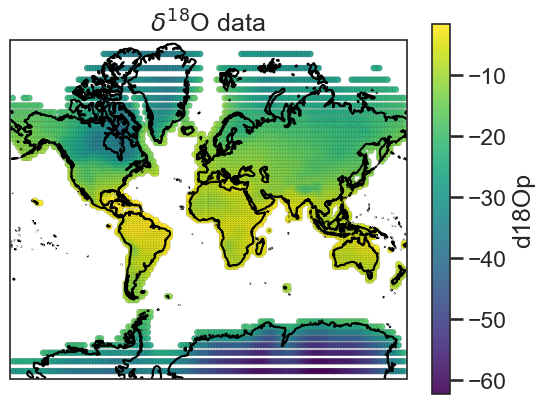

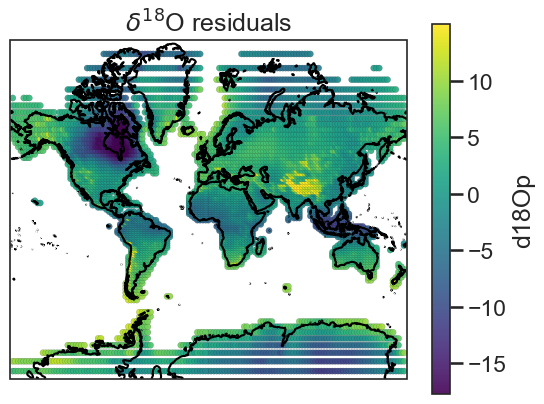

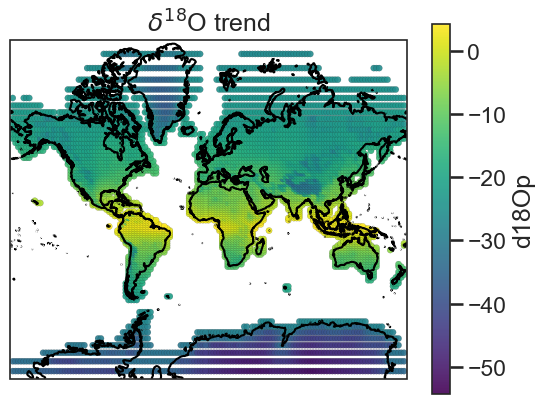

R2= 0.8837361561169225


In [13]:
detrended_df, results_dict = gutils.detrend_multiple_linear_regression(df,features = 'latabs_latReLU_ele_D')


fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['d18Op'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O data')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['residual'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O residuals')
plt.show() 
fig,ax = putils.plot_projected_data(df[['x','y']].values,detrended_df['trend'].values) # type:ignore
# plt.savefig('../output/data_exploration/itrace_map_example_chinazoom.png',dpi=500)
ax.set_title(r'$\delta^{18}$O trend')
plt.show()

res_df = gutils.multiple_linear_result_dict_to_df(result_dict=results_dict)
print('R2=',results_dict['r2'])

##### Isotope effect on all time slices

In [ ]:
# Uncomment if csv file is not available :
## Load all itrace time slices (we aggregate at 1yr resolution for avoiding memory outage)
# with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
#     itrace_sims = json.load(f)
# list_df = []
# for t,t_dict in itrace_sims.items(): # takes a while...
#     if t!='_comment':
#         itrace_df = gutils.get_preprocessed_itrace_data(true_kyr=t,data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',res=12,sim_kyr=t_dict['yrBPname'],sim_num=t_dict['num'],sim_suffix=t_dict['suffix'],sim_forcings=t_dict['forcings'],format='df',verbose=False) # res=12months=1yr
#         itrace_df['age_yrBP']=utils.get_yrBP_from_itrace_time(np.asarray(itrace_df['time']),int(t)*1000) #type:ignore
#         itrace_df = itrace_df[['age_yrBP','lat','lon','d18Op']] #type:ignore
#         list_df.append(itrace_df)
# itrace_df = pd.concat(list_df)

itrace_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/itrace_df_20ka_11ka_res12months_amount_weighted_2026_04_16.csv')

In [3]:
itrace_df.columns

Index(['Unnamed: 0', 'time', 'lat', 'lon', 'd18Op'], dtype='object')

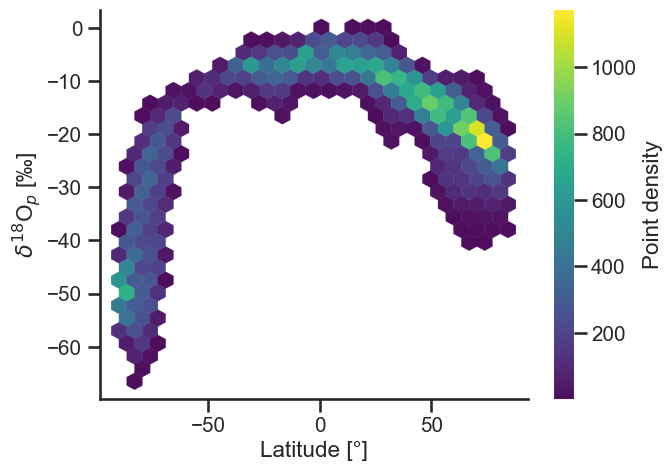

In [7]:
sns.set_theme(
    style="ticks",
    context="talk",
    font_scale=0.9,
    palette='colorblind'
)
# take a random sample of 10000 points for plotting

to_plot = itrace_df.sample(n=50000,random_state=42) #itrace_df.groupby(['lat','lon'])['d18Op'].mean().reset_index() # type: ignore
# sns.scatterplot(x= to_plot.lat,y=to_plot.d18Op,s=6,hue=to_plot.time.values) # type: ignore palette='viridis',hue=to_plot.age_yrBP.values
fig, ax = plt.subplots(figsize=(7, 5), sharex=True, sharey=True)
# ax_density, ax_scatter = axes

hb = ax.hexbin(
    to_plot.lat,
    to_plot.d18Op,
    gridsize=25,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,
)
cbar = fig.colorbar(hb, ax=ax, label='Point density')
cbar.outline.set_visible(False)

# sc = ax_scatter.scatter(
#     to_plot.lat,
#     to_plot.d18Op,
#     c=to_plot.time.values,
#     cmap='plasma',
#     s=35,
#     alpha=0.7,
#     edgecolors='none',
# )
# cbar = fig.colorbar(sc, ax=ax_scatter, label='Time [yr BP]')
# cbar.outline.set_visible(False)


# plt.grid(linestyle='--',alpha=0.4)
# for ax in axes :
ax.set_ylabel(r'$\delta^{18}$O$_p$ [‰]')
ax.set_xlabel('Latitude [°]')
ax.set_ylabel(r'$\delta^{18}$O$_p$ [‰]')
sns.despine(ax=ax)
plt.tight_layout()
plt.savefig('../output/essd_figs/fig_lateffect.png',dpi=500)
plt.show()

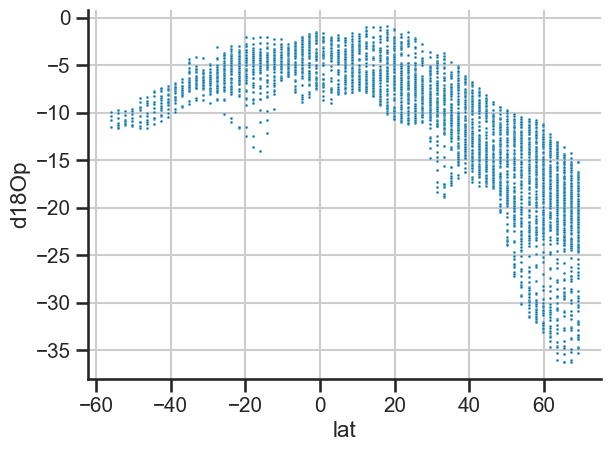

In [9]:
sns.scatterplot(x=to_plot.loc[(to_plot.lat > -58)&(to_plot.lat<71),'lat'],y=to_plot.loc[(to_plot.lat > -58)&(to_plot.lat<71),'d18Op'],s=4)
sns.despine()
plt.grid()
plt.tight_layout()
plt.show()

**We can try to find how to model this isotope effect**

1. **Splines?**

a=119268.75, b=-15.81°, sigma_n=5340.72°, sigma_s=2817.79°, e=-119273.95


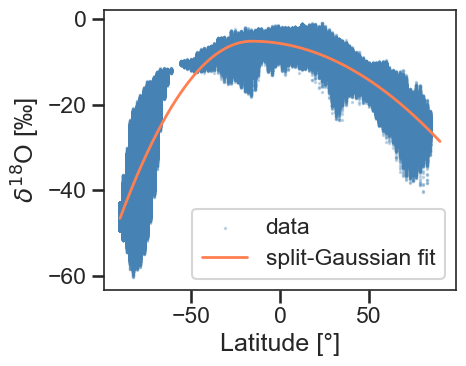

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

slice = itrace_df[itrace_df.time.between(11900,12000)]
lat  = slice["lat"].values
d18o = slice["d18Op"].values


def split_gaussian(lat, a, b, sigma_n, sigma_s, e):
    """
    a:       amplitude
    b:       peak latitude
    sigma_n: width of northern flank
    sigma_s: width of southern flank (smaller = steeper)
    e:       baseline (plateau value)
    """
    sigma = np.where(lat >= b, sigma_n, sigma_s)
    return a * np.exp(-((lat - b)**2) / (2 * sigma**2)) + e

p0 = [-55, 5, 45, 20, -3]

popt, _ = curve_fit(split_gaussian, lat, d18o, p0=p0, maxfev=10000)
print("a={:.2f}, b={:.2f}°, sigma_n={:.2f}°, sigma_s={:.2f}°, e={:.2f}".format(*popt))

lat_grid = np.linspace(-90, 90, 500)
plt.figure(figsize=(5, 4))
plt.scatter(lat, d18o, s=1, alpha=0.3, color="steelblue", label="data")
plt.plot(lat_grid, split_gaussian(lat_grid, *popt), color="coral", lw=2, label="split-Gaussian fit")
plt.xlabel("Latitude [°]")
plt.ylabel(r"$\delta^{18}$O [‰]")
plt.legend()
plt.tight_layout()
plt.show()


Not satisfactory : this is too much constrained on the data, we would rather model it using a basis function in our multiple linear trend model.

2. **Inverted U function such as cosh ?**

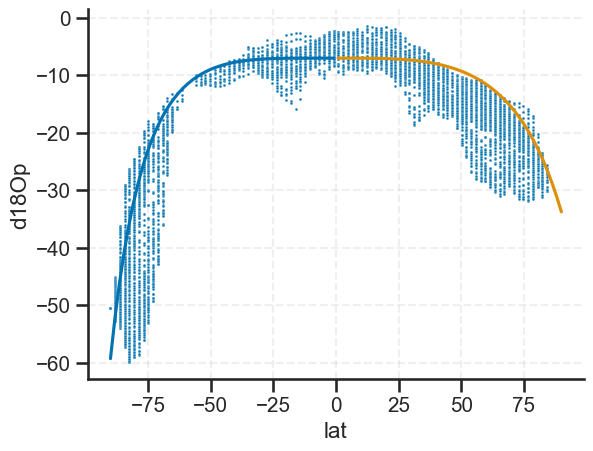

In [31]:
import math
lat = np.linspace(-90,90,100)
plt.figure()
sns.scatterplot(x= to_plot.lat,y=to_plot.d18Op,s=4) # type: ignore palette='viridis',hue=to_plot.age_yrBP.values
plt.plot(lat,-7*np.cosh(np.radians(-lat)**2.3))
plt.plot(lat,-7*np.cosh(np.radians(lat)**1.))
plt.grid(linestyle='--',alpha=0.3)
sns.despine()
plt.show()

cosh can indeed be a good basis functino for this problem, but needs the exponent to be found based on the slope of the sides of the U... This requires again a non linear fit on the data... 

3. **Piecewise linear function?**

Slopes: [ 1.20048416e+00  3.79367889e-01 -7.88465955e-04 -3.26039046e-01
 -3.22956261e-01]
Intercept: [56.41185353]


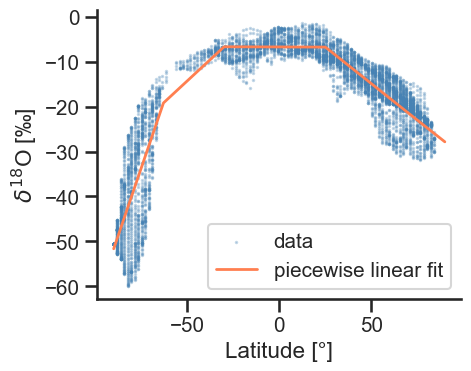

In [45]:
# Fit a piecewise linear function with three or four segments since the effect is not symmetric and has a flat part in the middle
from scipy.optimize import curve_fit

def piecewise_linear(lat, a1, a2, a3, a4, a5, b1,breakpoints=[-63,-30,25,60]):
    """
    Fit a piecewise linear function with breakpoints at specified latitudes.
    a1,a2,a3,a4,a5: slopes of each segment
    b1: intercept of the first segment.
    The intercepts of later segments are computed so the function is continuous.
    """
    lat = np.asarray(lat)
    b2 = b1 + (a1 - a2) * breakpoints[0]
    b3 = b2 + (a2 - a3) * breakpoints[1]
    b4 = b3 + (a3 - a4) * breakpoints[2]
    b5 = b4 + (a4 - a5) * breakpoints[3]

    conditions = [
        (lat < breakpoints[0]),
        (lat >= breakpoints[0]) & (lat < breakpoints[1]),
        (lat >= breakpoints[1]) & (lat < breakpoints[2]),
        (lat >= breakpoints[2]) & (lat < breakpoints[3]),
        (lat >= breakpoints[3])
    ]
    functions = [
        lambda x: a1 * x + b1,
        lambda x: a2 * x + b2,
        lambda x: a3 * x + b3,
        lambda x: a4 * x + b4,
        lambda x: a5 * x + b5  
    ]
    return np.piecewise(lat, conditions, functions)

p0 = [-0.1, -0.05, 0, 0.05, 0.1, -5]
popt, _ = curve_fit(piecewise_linear, to_plot.lat.values, to_plot.d18Op.values, p0=p0, maxfev=10000)
print("Slopes:", popt[:5])
print("Intercept:", popt[5:])

lat_grid = np.linspace(-90, 90, 500)
plt.figure(figsize=(5, 4))
plt.scatter(to_plot.lat, to_plot.d18Op, s=1, alpha=0.3, color="steelblue", label="data")
plt.plot(lat_grid, piecewise_linear(lat_grid, *popt), color="coral", lw=2, label="piecewise linear fit")
plt.xlabel("Latitude [°]")
plt.ylabel(r"$\delta^{18}$O [‰]")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()


**Conclusion on the latitude effect and how to model it.**

> **Spline** : not adapted to the multiple linear trend model logic, and risk of overfitting the data.
>
> **Cosh, or x^2** : good basis functions visually but making it asymmetrical requires a fit that would again not be adapted to the multiple linear fit logic as it means to adjust a parameter in a non-linear function (exponent inside the cosh or in the polynome)
>
> **PW linear** : the choice of the breakpoints number and their values is a strong hypothesis to make... Not adapted to  the multiple linear model. 
>
>
> The best option would be to stick with a very simplistic basis function such as the linear combination of lat and lat2, or cosh(x^2) in the multiple linear model, and improve the project later by splitting the domain into subdomains (climate zones?) in order to refine the trend model locally. The complicated shape would be thus decomposed into smaller segments, probably appropriate to a more simple linear modelling.
>
> In the mean time, we just have to mention that our quadratic or cosh approximation of the latitude effect is far from perfect and that the residuals will still exhibit structured trends because of that, making the residuals fields not perfectly stationnary. 
>
> The consequence will be that the variograms of the residuals will have a higher sill than expected and may not stabilize well around this sill, and/or exhibit anisotropy in the N/S direction.

##### What are the statistics of itrace across time ?

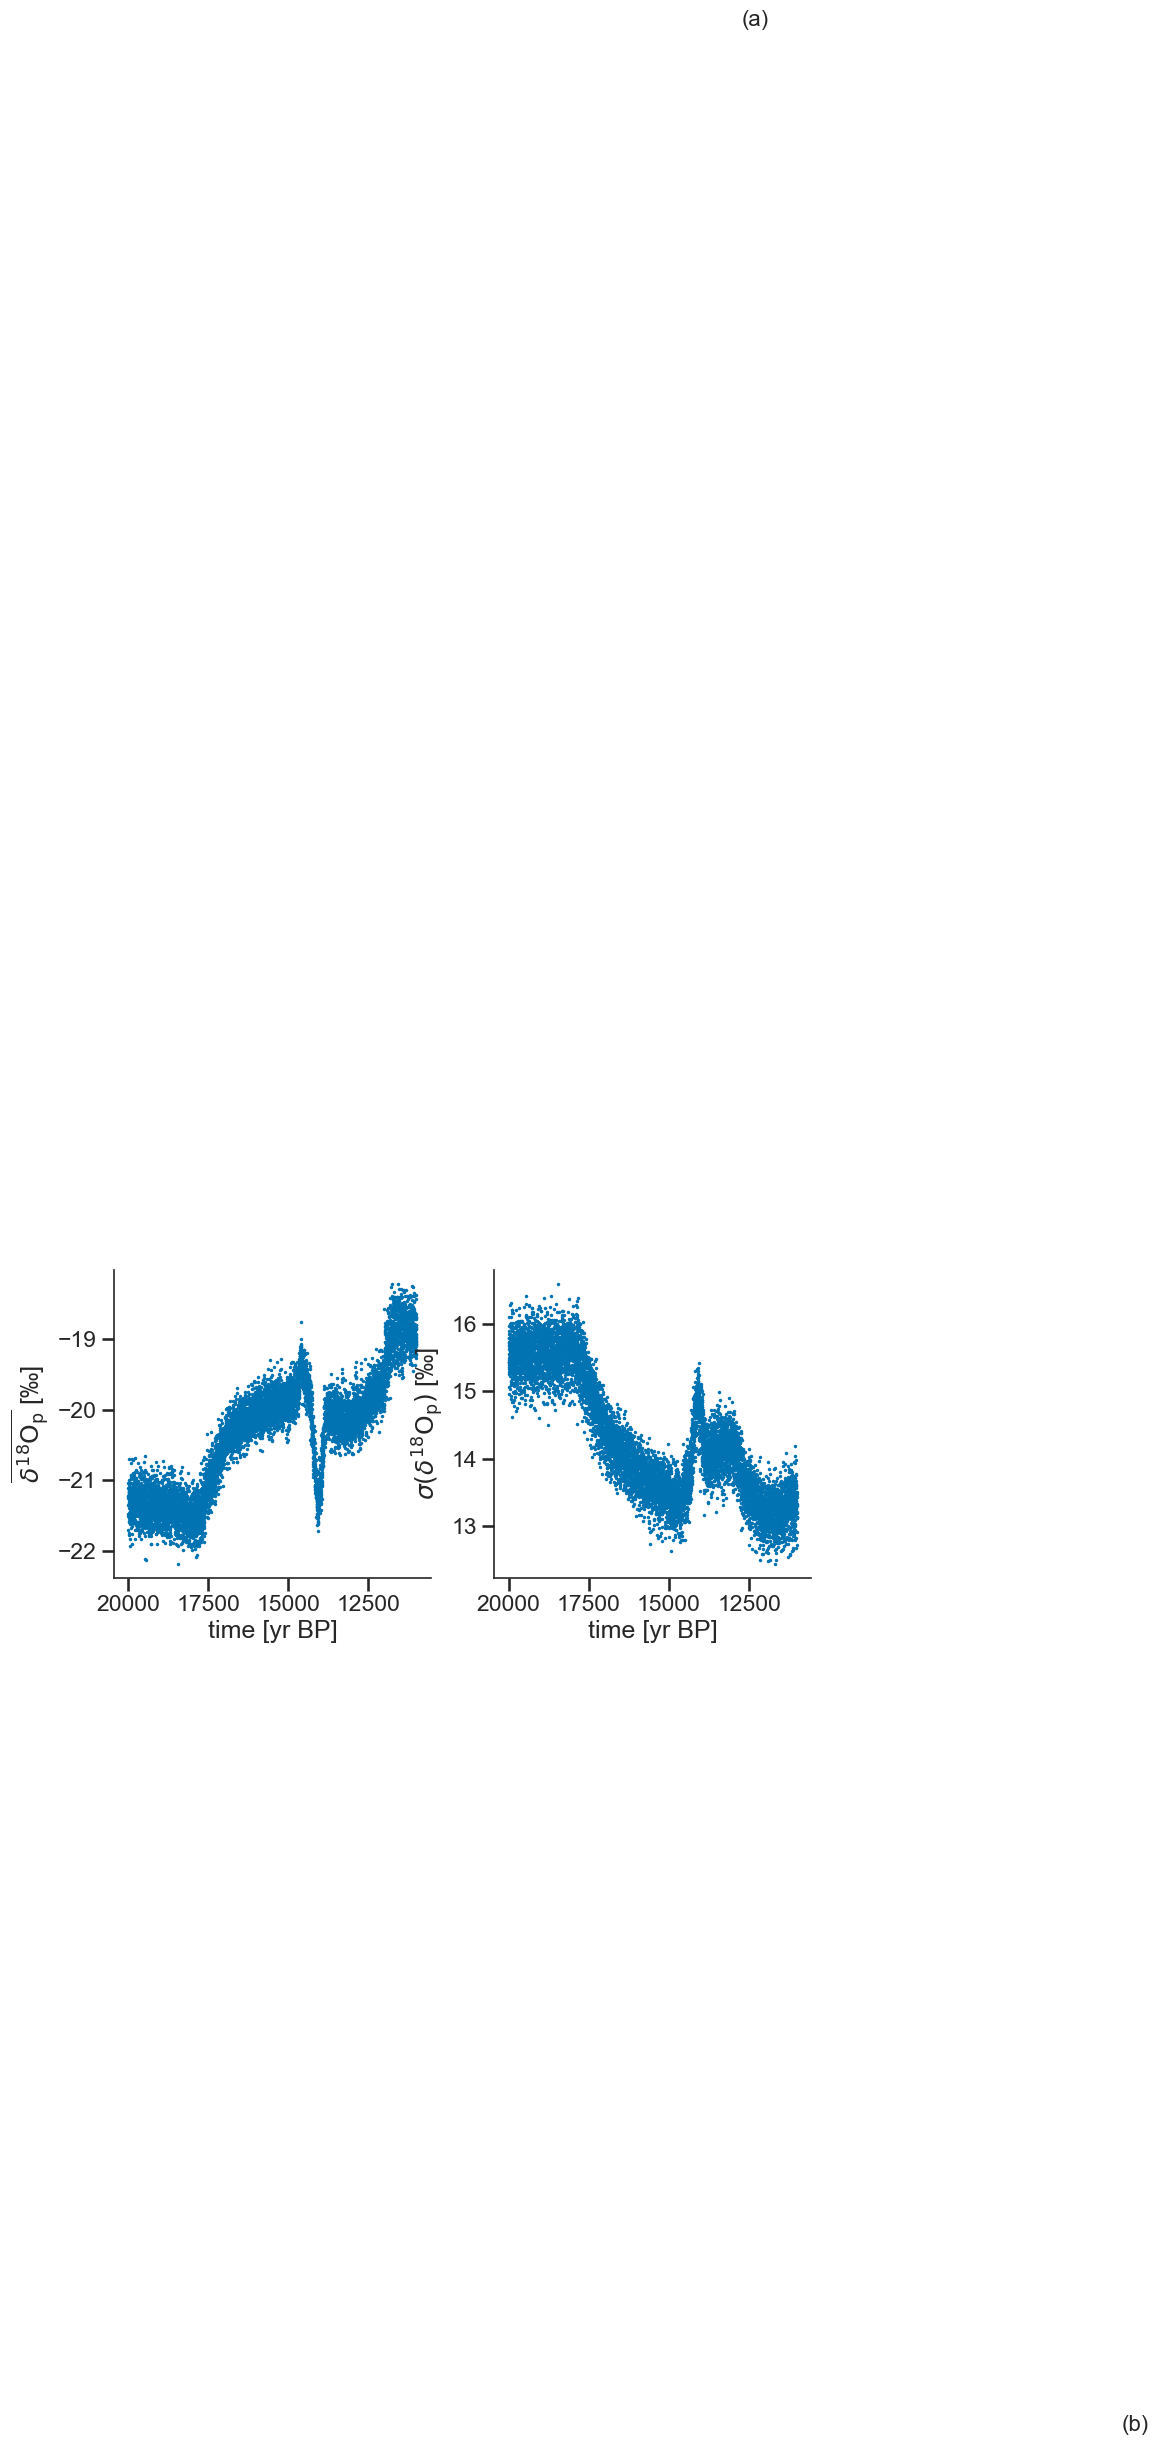

In [ ]:
itrace_df = pd.read_csv('/media/luluxette/T7_Shield/pdm/itrace_df_20ka_11ka_res12months_amount_weighted_2026_04_16.csv')


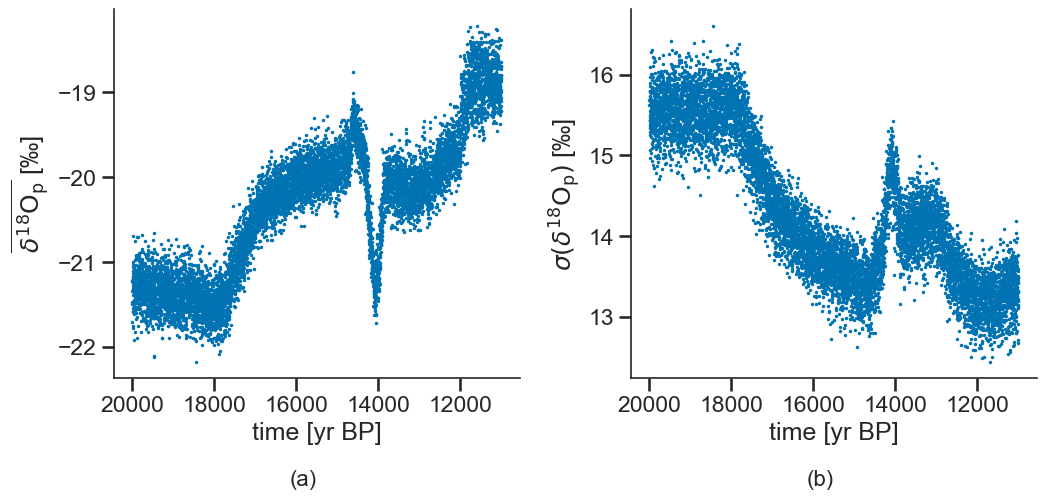

In [36]:

fig,axes = plt.subplots(1,2,figsize=(11,5.5))
ax1,ax2=axes
df_mean = itrace_df.groupby('time')['d18Op'].mean()
ax1.scatter(df_mean.index.values,df_mean.values,s=1)
sns.despine()
ax1.set_xlabel('time [yr BP]')
ax1.set_ylabel(r'$\overline{\delta^{18}\text{O}_\text{p}}$ [‰]')
ax1.invert_xaxis()
ax1.text(0.5, -0.3, '(a)', transform=ax1.transAxes, fontsize=16, va='bottom', ha='right')


df_std = itrace_df.groupby('time')['d18Op'].std()
ax2.scatter(df_std.index.values,df_std.values,s=1)
sns.despine()
ax2.set_xlabel('time [yr BP]')
ax2.set_ylabel(r'$\sigma(\delta^{18}\text{O}_\text{p})$ [‰]')
ax2.invert_xaxis()
ax2.text(0.5, -0.3, '(b)', transform=ax2.transAxes , fontsize=16, va='bottom', ha='right')
plt.tight_layout()
plt.savefig('../output/essd_figs/fig_itrace_meanstd.png',dpi=500)
plt.show()

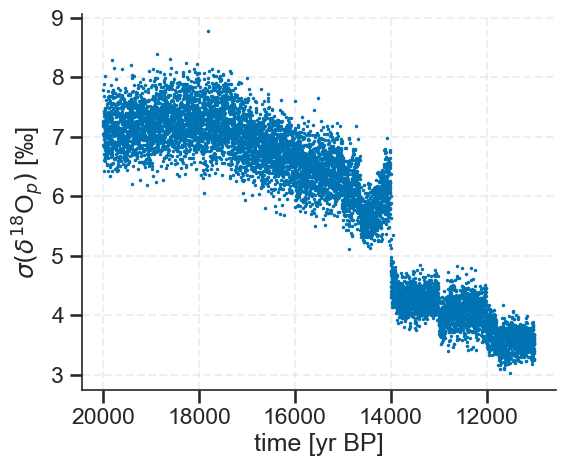

In [ ]:
# observe by band of lat
fig,ax = plt.subplots(figsize=(6,5))
df_std = itrace_df[itrace_df.lat.between(50,60)].groupby('age_yrBP')['d18Op'].std()

plt.scatter(df_std.index.values,df_std.values,s=1)
plt.grid(linestyle='--',alpha=0.3)
sns.despine()
plt.xlabel('time [yr BP]')
plt.ylabel(r'$\sigma(\delta^{18}$O$_p)$ [‰]')
ax.invert_xaxis()
plt.tight_layout()
# plt.savefig('../output/results_figs/itrace_std_over_time.png',dpi=500)
plt.show()

##### Variogram for multiple time slices in a 1000yr slice

**Global variogram computation:** 
1. Convert the xarray DataArray into a dataframe 
1. Project coordinates
1. Loop on all time steps, compute variogram, append results to lists
1. Aggregate the results into one variogram (details below)
1. Plot

> Steps 2. and 3. are gathered in function ```gutils.iterative_variogram_computations```\
> Step 4. is achieved by function ```gutils.aggregate_variograms```

In [23]:
fp = '../output/variograms/itrace/tests/vario_df' #f'../output/variograms/itrace_alltimes_res{res}_trend_lat_quad_ele_D_P_maxlag{str(maxlag):.1e}_nlags{nlags}'
print('All directions')
# depending on the chosen resolution when loading itrace_ds, it can take up to 2 hours...
bin_count,gammas, _, dict_results = gutils.iterative_variogram_computations(itrace_ds,ref_bins=ref_bins,trend='multiple_linear_ele_latabs_latReLU_quad_D_P')
df_all = gutils.aggregate_variograms(bin_counts=bin_count,gammas=gammas,bins=ref_bins)
df_all.to_csv(f'{fp}.csv')
with open(f'{fp}.json', 'w') as fp:
    json.dump(dict_results, fp)
# print('computation dir=0')
# bin_count0,gammas0, _, dict_results = gutils.iterative_variogram_computations(df,ref_bins,direction=0)
# df0 = gutils.aggregate_variograms(bin_counts=bin_count0,gammas=gammas0,bins=ref_bins)
# df0.to_csv('../output/variograms/global_alltimes_variogram_d0_df_itrace.csv')

# print('computation dir=45')
# bin_count45,gammas45, _, dict_results = gutils.iterative_variogram_computations(df,ref_bins,direction=45)
# df45 = gutils.aggregate_variograms(bin_counts=bin_count45,gammas=gammas45,bins=ref_bins)
# df45.to_csv('../output/variograms/global_alltimes_variogram_d45_df_itrace.csv')

# print('computation dir=90')
# bin_count90,gammas90, _, dict_results = gutils.iterative_variogram_computations(df,ref_bins,direction=90)
# df90 = gutils.aggregate_variograms(bin_counts=bin_count90,gammas=gammas90,bins=ref_bins)
# df90.to_csv('../output/variograms/global_alltimes_variogram_d90_df_itrace.csv')

# print('computation dir=135')
# bin_count135,gammas135, _, dict_results = gutils.iterative_variogram_computations(df,ref_bins,direction=135)
# df135 = gutils.aggregate_variograms(bin_counts=bin_count135,gammas=gammas135,bins=ref_bins)
# df135.to_csv('../output/variograms/global_alltimes_variogram_d135_df_itrace.csv')

All directions


  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:13<00:00,  2.72s/it]


In [24]:
df_all = pd.read_csv('../output/variograms/itrace/tests/vario_df.csv')
# df0 = pd.read_csv('../output/variograms/global_variogram_d0_df_itrace.csv')
# df45 = pd.read_csv('../output/variograms/global_variogram_d45_df_itrace.csv')
# df90 = pd.read_csv('../output/variograms/global_variogram_d90_df_itrace.csv')
# df135 = pd.read_csv('../output/variograms/global_variogram_d135_df_itrace.csv')


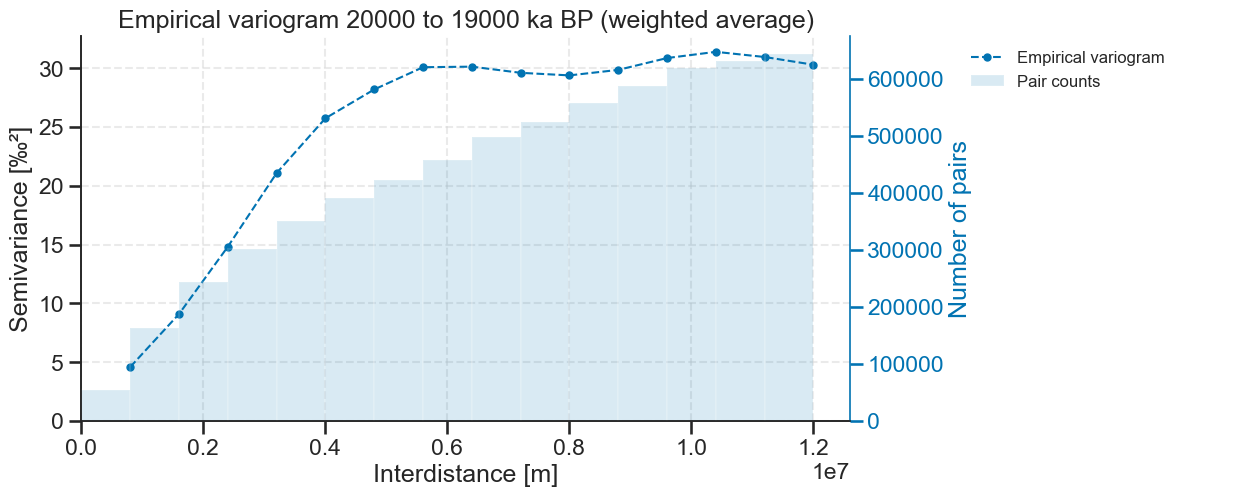

In [25]:
# plot global variogram - all directions
fig, ax = putils.plot_variogram_from_bins_and_gamma(df_all['lag'],df_all['gamma'],title='20000 to 19000 ka BP (weighted average)',counts=df_all['count']) #type:ignore
plt.show()
# plot directional variograms
# list = [df0,df45,df90,df135]
# list_dir=[0,45,90,135]
# fig,axes=plt.subplots(2,2,figsize=(17,9))
# for i in range(2):
#     for j in range(2):
#         df_to_plot = list[i+2*j]
#         axes[i,j] = putils.plot_variogram_from_bins_and_gamma(df_to_plot['lag'],df_to_plot['gamma'],time=f'11.7 to 11 ka BP - {list_dir[i+2*j]}',counts=df_to_plot['count'],ax_= axes[i,j])
#         axes[i,j].set_title(f'Dir={list_dir[i+2*j]}')
# plt.show()

#### Elevation via PHIS variable

Let us plot the d18Op values versus the altitude 

loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years


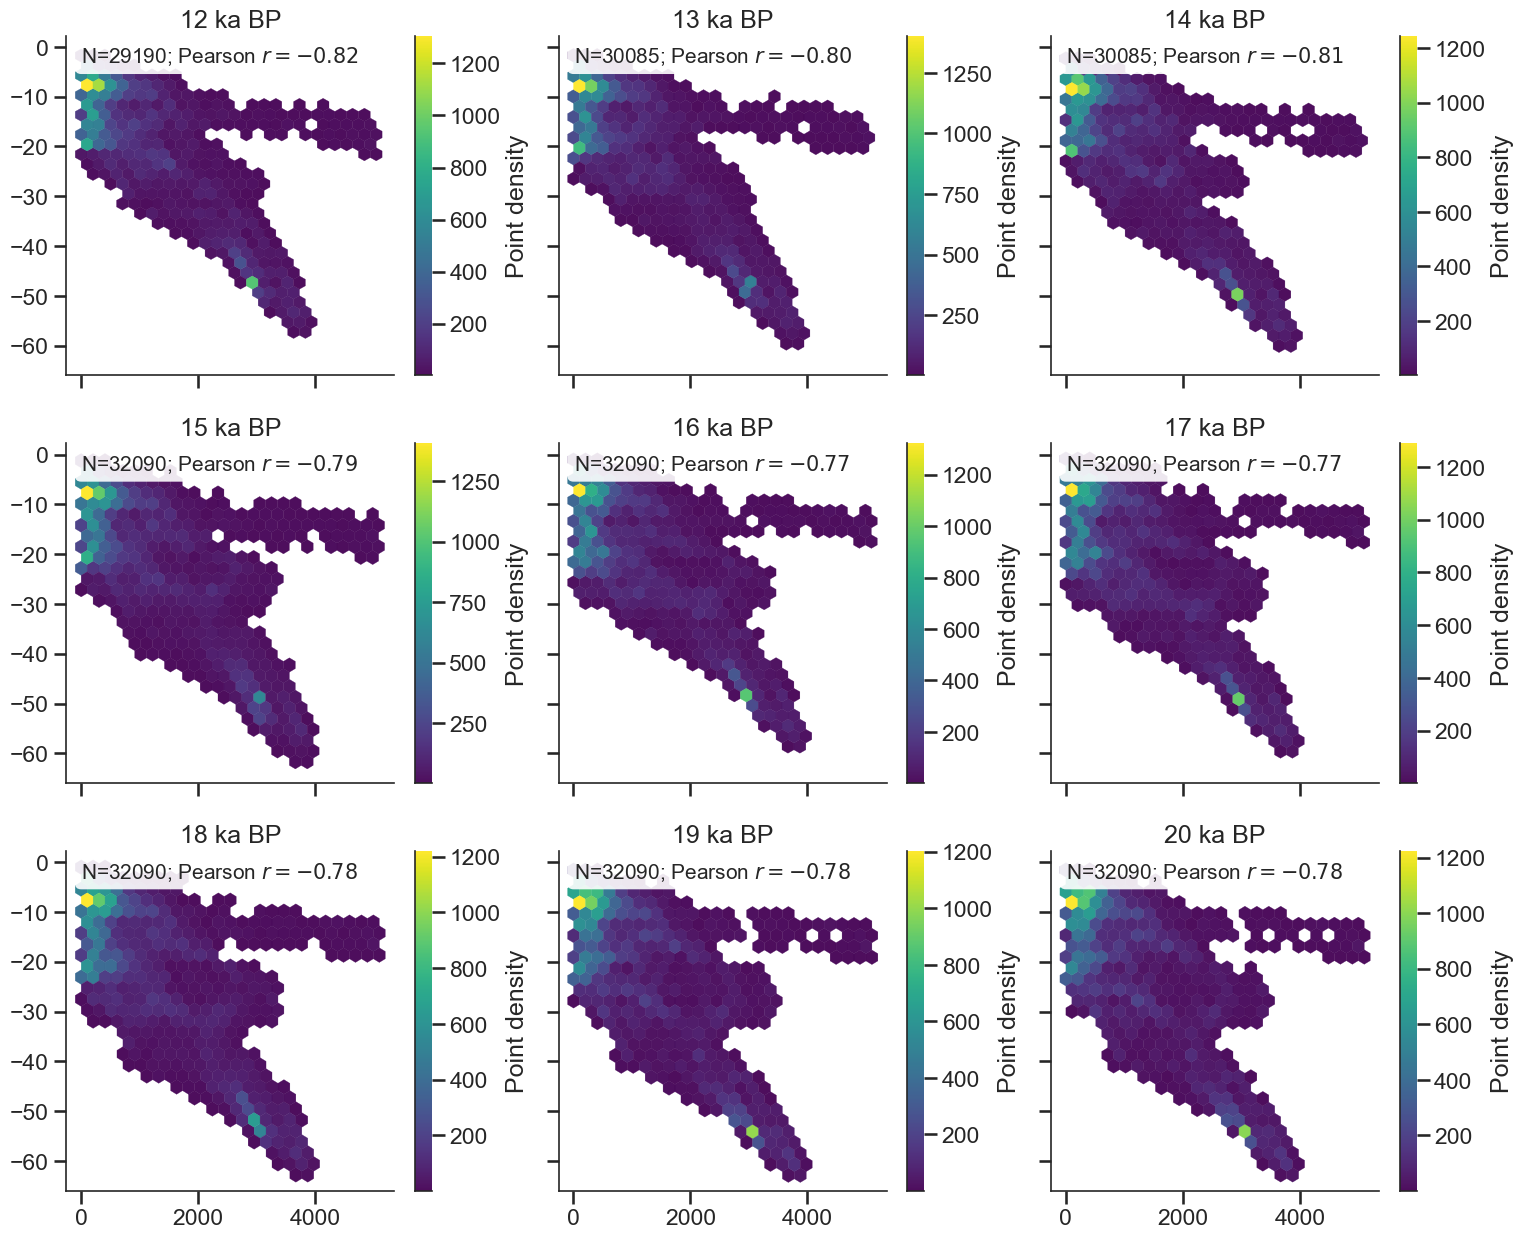

In [2]:
# load json dict for itrace sims 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)

fig, axes = plt.subplots(3, 3, figsize=(18, 15),sharex=True,sharey=True)

i=0
for sim,sim_dict in sims.items() :
    itrace_vals = gutils.get_preprocessed_itrace_data(true_kyr=int(sim),
                                                      sim_forcings=sim_dict['forcings'],
                                                      sim_kyr = sim_dict['yrBPname'],
                                                      sim_num=sim_dict['num'],
                                                      regions=None,
                                                      sim_suffix=sim_dict['suffix'],
                                                      buffer_km=0,
                                                      P=True,
                                                      d18O=True,
                                                      Ele=True,
                                                      format='df',
                                                      res=200)
    # metrics
    r, p_value = pearsonr(itrace_vals.ele.values,itrace_vals.d18Op.values)
    N = len(itrace_vals)

    ax=axes[i//3,i % 3]
    hb = ax.hexbin(
        itrace_vals.ele.values,
        itrace_vals.d18Op.values,
        gridsize=25,
        cmap='viridis',
        mincnt=1,
        linewidths=0.2,
        alpha=0.95,
    )
    cbar = fig.colorbar(hb, ax=ax, label='Point density')
    cbar.outline.set_visible(False) #type:ignore
    
    ax.text(0.15, 0.4,
        fr'N={N}; Pearson $r={r:.2f}$',
        va='top', ha='left', fontsize=15,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9)
        )



    sns.despine()
    ax.set_title(f'{sim} ka BP')
    i=i+1
    
plt.show()

plt.close('all')

loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years
loading itrace files
   bins of width=200 years


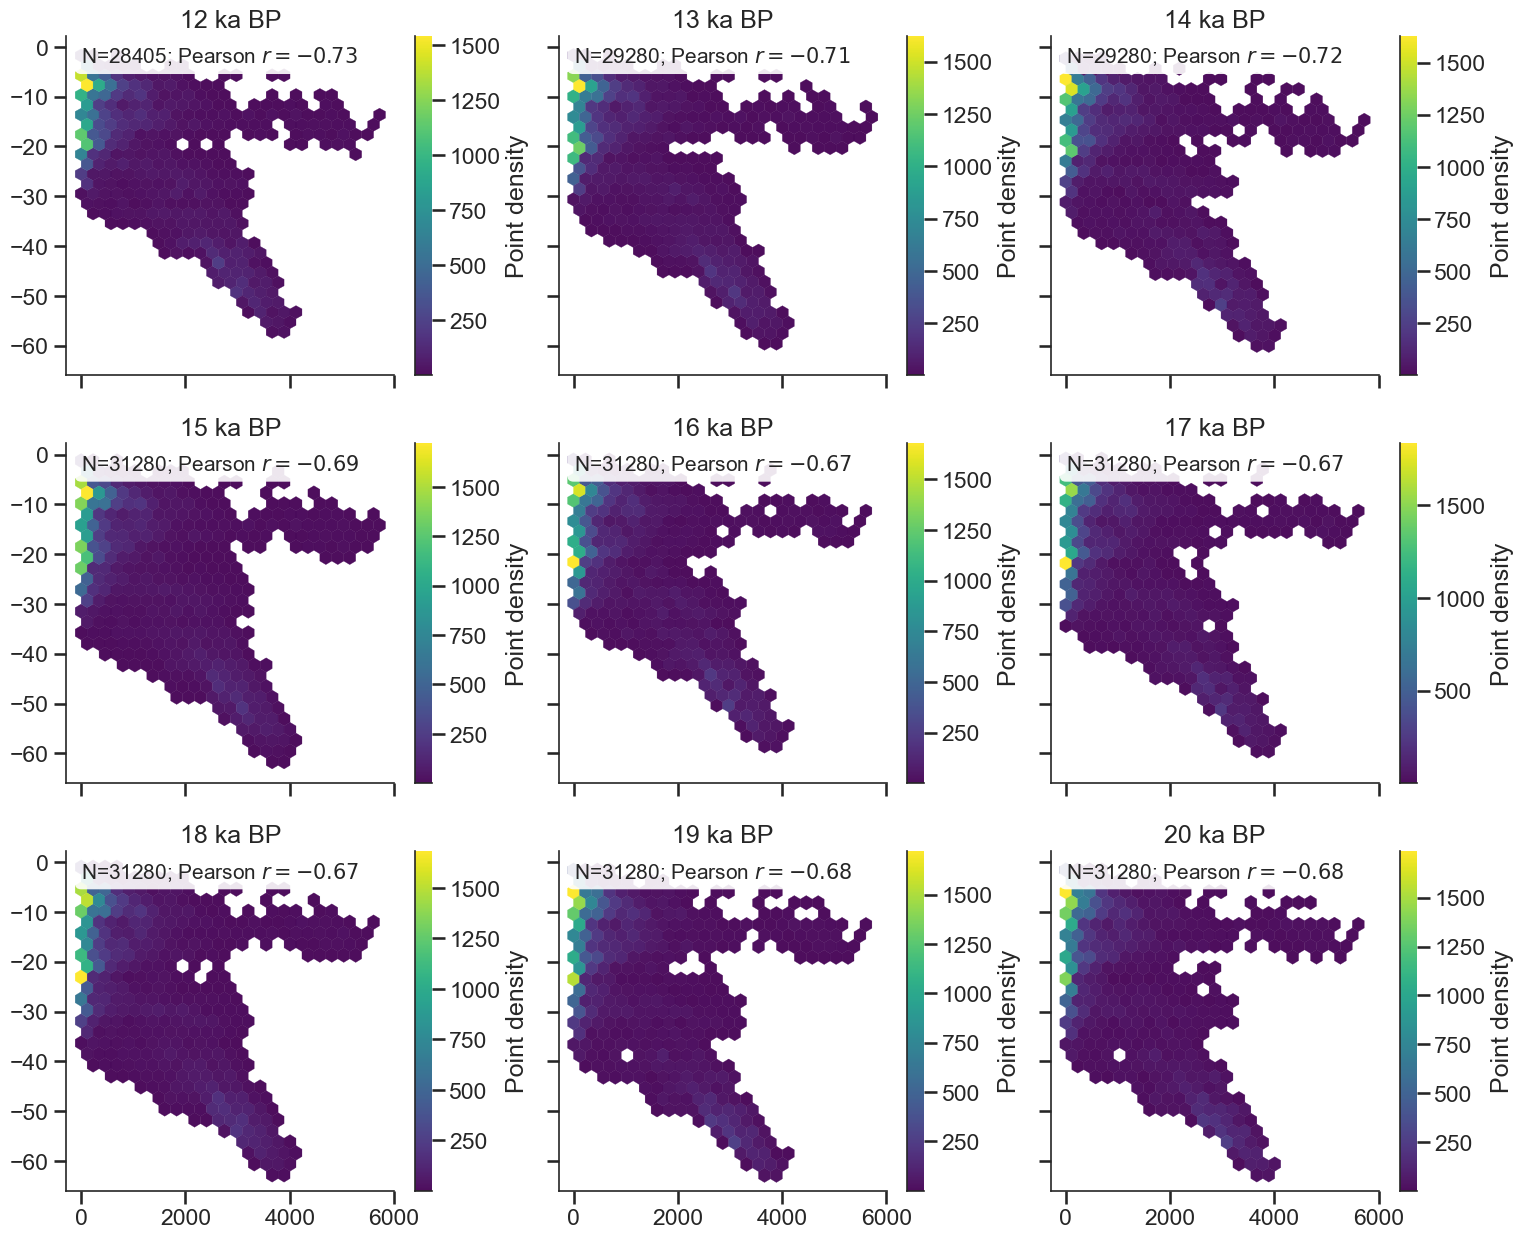

In [3]:
# load json dict for itrace sims 
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)

fig, axes = plt.subplots(3, 3, figsize=(18, 15),sharex=True,sharey=True)

i=0
for sim,sim_dict in sims.items() :
    itrace_vals = gutils.get_preprocessed_itrace_data(true_kyr=int(sim),
                                                      sim_forcings=sim_dict['forcings'],
                                                      sim_kyr = sim_dict['yrBPname'],
                                                      sim_num=sim_dict['num'],
                                                      regions=None,
                                                      sim_suffix=sim_dict['suffix'],
                                                      buffer_km=0,
                                                      P=True,
                                                      d18O=True,
                                                      Ele=False,
                                                      format='df',
                                                      res=200)
    itrace_vals = gutils.add_external_variables_to_lonlat_df(itrace_vals,variables=['ele'])
    # metrics
    r, p_value = pearsonr(itrace_vals.ele.values,itrace_vals.d18Op.values)
    N = len(itrace_vals)

    ax=axes[i//3,i % 3]
    hb = ax.hexbin(
        itrace_vals.ele.values,
        itrace_vals.d18Op.values,
        gridsize=25,
        cmap='viridis',
        mincnt=1,
        linewidths=0.2,
        alpha=0.95,
    )
    cbar = fig.colorbar(hb, ax=ax, label='Point density')
    cbar.outline.set_visible(False) #type:ignore

    ax.text(0.15, 0.4,
        fr'N={N}; Pearson $r={r:.2f}$',
        va='top', ha='left', fontsize=15,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9)
    )

    sns.despine()
    ax.set_title(f'{sim} ka BP')
    i=i+1
    
plt.show()

plt.close('all')

Let us evaluate how much error is introduced when using itrace d18O (cell's mean) at a punctual location:

we can compute the mean absolute difference in altitude at SISAL points (lat,lon) depending on whether the altitude is defined with the DEM or with the cell's mean in itrace grid. 


In [4]:
# load sisal data as if we wanted to krige the dataset
sisal_df = gutils.get_sisal_data_for_kriging(res=200,temp_ds_name='itrace',temp_ds_path='/media/luluxette/T7_Shield/pdm/itrace/',verbose=False)
sisal_locs = sisal_df


converting speleothem data to drip-water equivalents...
sisal dataframe is ready


In [5]:
sisal_df['kaBP']=sisal_df['age']//1000+1
sisal_df['kaBP']=sisal_df['kaBP'].astype('int')

In [12]:
sisal_df.columns

Index(['mineralogy', 'age', 'age_method', 'age_uncert_pos', 'age_uncert_neg',
       'entity_id', 'sample_id', 'site_id', 'site_name', 'lon', 'lat', 'ele',
       'd18O_measurement', 'd18O_precision', 'd18Op_VSMOW_exactconv',
       'd18Op_VSMOW_linearized', 'd18Oc_VSMOW', 'T_itrace', 'binned_age',
       'kaBP'],
      dtype='object')

In [78]:
from tqdm import tqdm
from scipy.interpolate import griddata

# for each time slice in sisal df, load the corresponding itrace elevation file and find the itrace elevatino that corresponds to this location (closest itrace cell center)
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sims = dict((k,itrace_sims[k]) for k in ('12','13','14','15','16','17','18','19','20') if k in itrace_sims)
list_df = []

for t,sisal_t in tqdm(sisal_df.groupby('kaBP',observed=True)):
    sim_dict = itrace_sims[str(t)]
    itrace_ele = gutils.get_preprocessed_itrace_data(true_kyr=t,
                                                     sim_forcings=sim_dict['forcings'],
                                                     sim_kyr = sim_dict['yrBPname'],
                                                     sim_num=sim_dict['num'],
                                                     regions=None,
                                                     sim_suffix=sim_dict['suffix'],
                                                     P=False,
                                                     d18O=True,
                                                     Ele=True,
                                                     format='df',
                                                     res=200,
                                                     verbose =False)
    print(itrace_ele.columns)
    if any(itrace_ele.lon>180):
        itrace_ele['lon']= utils.convert_lon_0_360_to_neg180_180(itrace_ele.lon.values)
    
    for i,rec in sisal_t.groupby('binned_age',observed=True):
        rec = rec[['lat','lon','ele','site_id','d18Op_VSMOW_exactconv']].groupby(['lon','lat'],as_index=False).mean()
        obs_points = np.column_stack((rec.lat, rec.lon))
        grid_points = np.column_stack((itrace_ele.lat, itrace_ele.lon))
        
        rec['ele_itrace'] = griddata(grid_points, itrace_ele['ele'].values, obs_points, method='linear')
        rec['d18O_itrace'] = griddata(grid_points, itrace_ele['d18Op'].values, obs_points, method='linear')

        list_df.append(rec)
    
    df_elevation = pd.concat(list_df)

  0%|          | 0/9 [00:00<?, ?it/s]

Index(['lon', 'lat', 'time', 'd18Op', 'ele'], dtype='object')
90
88
82
82


 11%|█         | 1/9 [01:27<11:36, 87.02s/it]

84
Index(['lon', 'lat', 'time', 'd18Op', 'ele'], dtype='object')
81
77
76


 22%|██▏       | 2/9 [02:47<09:41, 83.06s/it]

...

53
Index(['lon', 'lat', 'time', 'd18Op', 'ele'], dtype='object')
52
50
57
56


 89%|████████▉ | 8/9 [13:15<01:48, 108.40s/it]

54
Index(['lon', 'lat', 'time', 'd18Op', 'ele'], dtype='object')
52
52
50
47


100%|██████████| 9/9 [15:03<00:00, 100.43s/it]

50


In [79]:
# Results : mean absolute difference between ele and ele_itrace, and the corresponding delta18
df_elevation['ele_diff']=df_elevation['ele']-df_elevation['ele_itrace']
df_elevation['d18_diff']=df_elevation['d18Op_VSMOW_exactconv']-df_elevation['d18O_itrace']

df_elevation.describe()

,lon,lat,ele,site_id,ele_itrace,d18O_itrace,ele_diff
count,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000,2842.000000
mean,31.060134,14.556467,660.426316,150.652913,608.242212,-8.474290,52.184104
std,87.434907,27.979478,717.468861,103.526322,523.541172,2.553178,472.712846
min,-133.319000,-45.373500,-45.000000,1.000000,9.881677,-16.005591,-1340.682810
25%,-44.628100,-8.530000,148.000000,68.000000,254.148430,-10.424713,-210.196712
50%,32.105600,26.230000,400.000000,144.000000,449.960214,-8.617228,-30.905121
75%,109.983300,37.890000,960.000000,234.000000,800.051596,-6.559839,259.363957
max,175.080000,56.162000,3800.000000,366.000000,3240.682810,-1.899505,2083.860038


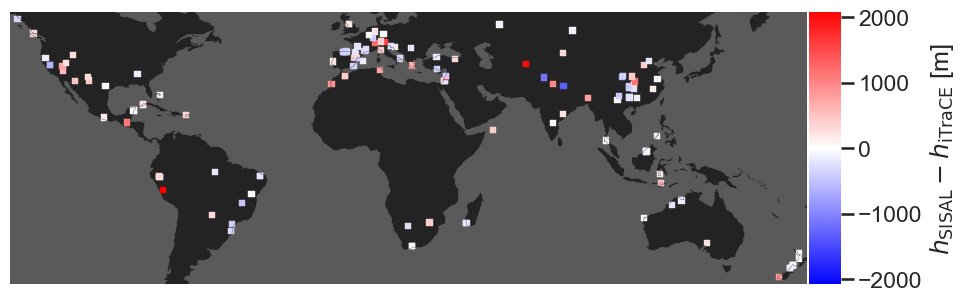

In [91]:
fig,ax = putils.plot_latlon_platecarree_df(df_elevation[['lat','lon','ele_diff']].groupby(['lat','lon'],as_index=False).mean(),title='',
                                  countries_borders=False,
                                  qty_col='ele_diff',
                                  qty_label=r'$h_\text{SISAL}-h_\text{iTraCE}$',
                                  unit='m',
                                  cmap_sym0=True,
                                  cmap='bwr',
                                  oceancolor="#5B5A5A",
                                  landcolor="#232323") #type:ignore
plt.savefig('../output/data_exploration/elevation_diff.png',dpi=300)
plt.show()

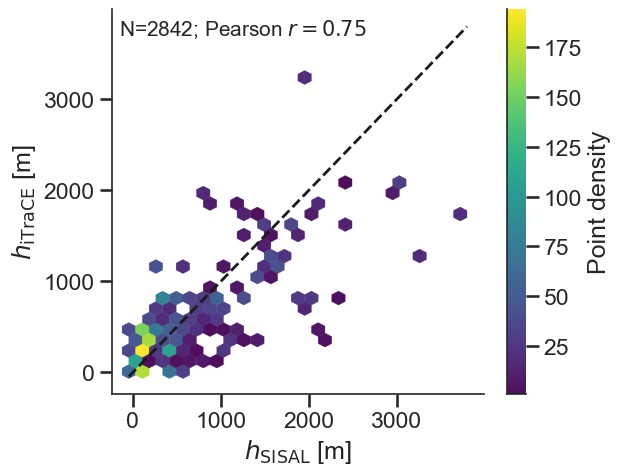

In [ ]:
fig,ax = plt.subplots(1,1,figsize=(6,5))
r, p_value = pearsonr(df_elevation.ele.values,df_elevation.ele_itrace.values)
N = len(df_elevation)
ax.text(x=0.02,
        y=0.98,
        s=fr'N={N}; Pearson $r={r:.2f}$',
        va='top', ha='left', fontsize=15,
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9),
    )
hb = ax.hexbin(
    df_elevation['ele'],
    df_elevation['ele_itrace'],
    gridsize=25,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,
)
ax.set_xlabel(r'$h_\text{SISAL}$ [m]')
ax.set_ylabel(r'$h_\text{iTraCE}$ [m]')
cbar = fig.colorbar(hb, ax=ax, label='Point density')
cbar.outline.set_visible(False)
sns.despine()
# reference line and common layout
min_val = min(df_elevation['ele'].min(), df_elevation['ele_itrace'].min())
max_val = max(df_elevation['ele_itrace'].max(), df_elevation['ele'].max())
ax.plot([min_val, max_val], [min_val, max_val], linestyle='--', linewidth=2, color='0.1', label='1:1 line')
plt.savefig('../output/data_exploration/scatterplot_DEM_vs_cell-altitude.png',dpi=300)
plt.show()

In [86]:
df_elevation['d18_diff'] = df_elevation.d18_diff.astype('float64')

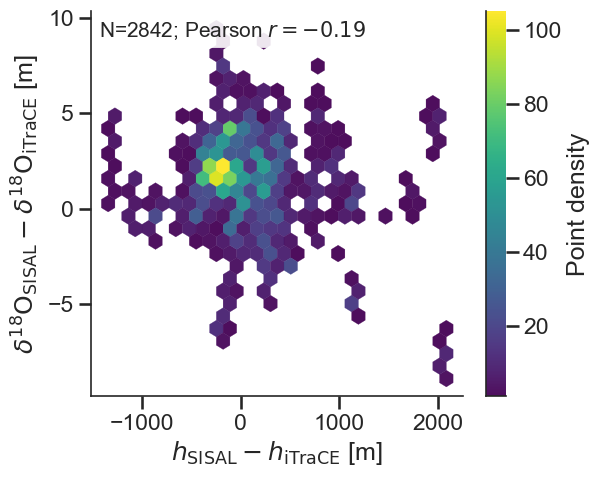

In [87]:
fig,ax = plt.subplots(1,1,figsize=(6,5))
r, p_value = pearsonr(df_elevation.ele_diff.values,df_elevation.d18_diff.values)
N = len(df_elevation)
ax.text(x=0.02,
        y=0.98,
        s=fr'N={N}; Pearson $r={r:.2f}$',
        va='top', ha='left', fontsize=15,
        transform=ax.transAxes,
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='none', alpha=0.9),
    )
hb = ax.hexbin(
    df_elevation['ele_diff'],
    df_elevation['d18_diff'],
    gridsize=25,
    cmap='viridis',
    mincnt=1,
    linewidths=0.2,
    alpha=0.95,
)
ax.set_xlabel(r'$h_\text{SISAL}-h_\text{iTraCE}$ [m]')
ax.set_ylabel(r'$\delta^{18}\text{O}_\text{SISAL}-\delta^{18}\text{O}_\text{iTraCE}$ [m]')
cbar = fig.colorbar(hb, ax=ax, label='Point density')
cbar.outline.set_visible(False)
sns.despine()

plt.show()

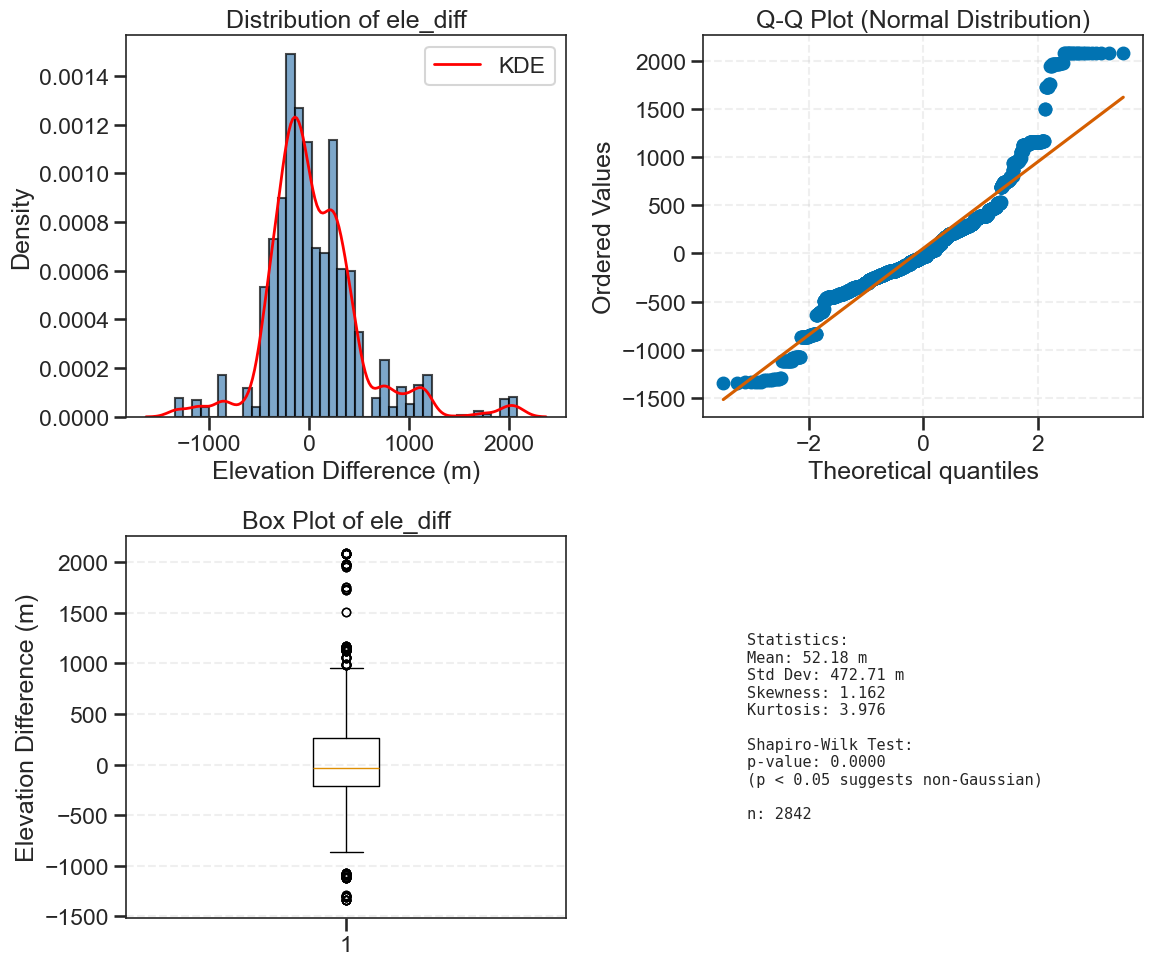

In [ ]:
from scipy import stats

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Histogram with KDE
axes[0, 0].hist(df_elevation['ele_diff'], bins=40, density=True, alpha=0.7, color='steelblue', edgecolor='black')
sns.kdeplot(data=df_elevation, x='ele_diff', ax=axes[0, 0], color='red', linewidth=2, label='KDE')
axes[0, 0].set_xlabel('Elevation Difference (m)')
axes[0, 0].set_ylabel('Density')
axes[0, 0].set_title('Distribution of ele_diff')
axes[0, 0].legend()

# Q-Q plot
stats.probplot(df_elevation['ele_diff'], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title('Q-Q Plot (Normal Distribution)')
axes[0, 1].grid(alpha=0.3)

# Box plot
axes[1, 0].boxplot(df_elevation['ele_diff'], vert=True)
axes[1, 0].set_ylabel('Elevation Difference (m)')
axes[1, 0].set_title('Box Plot of ele_diff')
axes[1, 0].grid(alpha=0.3, axis='y')

# Statistics
stat_text = f"""Statistics:
Mean: {df_elevation['ele_diff'].mean():.2f} m
Std Dev: {df_elevation['ele_diff'].std():.2f} m
Skewness: {stats.skew(df_elevation['ele_diff']):.3f}
Kurtosis: {stats.kurtosis(df_elevation['ele_diff']):.3f}

Shapiro-Wilk Test:
p-value: {stats.shapiro(df_elevation['ele_diff'])[1]:.4f}
(p < 0.05 suggests non-Gaussian)

n: {len(df_elevation)}"""

axes[1, 1].text(0.1, 0.5, stat_text, fontsize=11, family='monospace',
                verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

In [ ]:
from tqdm import tqdm
from scipy.interpolate import griddata
import numpy as np
import xarray as xr


def get_dem_points_in_cell(dem_da, lat_center, lon_center, dlat, dlon):
    lat_min = lat_center - dlat / 2
    lat_max = lat_center + dlat / 2
    lon_min = lon_center - dlon / 2
    lon_max = lon_center + dlon / 2

    subset = dem_da.where(
        (dem_da.lat >= lat_min) & (dem_da.lat < lat_max) &
        (dem_da.lon >= lon_min) & (dem_da.lon < lon_max),
        drop=True
    )
    return subset


# for each time slice in sisal df, load the corresponding itrace elevation file and find the itrace elevation that corresponds to this location (closest itrace cell center)
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

# Keep only the simulations of interest (the keys represent 1000 yr BP slices)
sim = '12'
list_df = []
dem_file = '../data/elevation/ETOPO_2022_v1_60s_N90W180_surface.nc'
dem = xr.open_dataset(dem_file, engine='netcdf4')
dem_da = dem.z

sim_dict = itrace_sims[str(t)]
itrace_ele = gutils.get_preprocessed_itrace_data(
    true_kyr=int(t),
    sim_forcings=sim_dict['forcings'],
    sim_kyr=sim_dict['yrBPname'],
    sim_num=sim_dict['num'],
    regions=None,
    sim_suffix=sim_dict['suffix'],
    P=False,
    d18O=False,
    Ele=True,
    format='xr',
    res=200,
    verbose=False,
)
itrace_ele = itrace_ele.assign_coords(
    lon=utils.convert_lon_0_360_to_neg180_180(itrace_ele.lon.values)
)

lat_centers = np.sort(np.unique(itrace_ele['lat'].values))
lon_centers = np.sort(np.unique(itrace_ele['lon'].values))
dlat = np.median(np.diff(lat_centers))
dlon = np.median(np.diff(lon_centers))

std_elev = np.full((len(lat_centers), len(lon_centers)), np.nan)
    
print('N=',len(lat_centers))
for i, lat0 in enumerate(lat_centers):
    print(i)
    for j, lon0 in enumerate(lon_centers):
        subset = get_dem_points_in_cell(
            dem_da,
            lat_center=lat0,
            lon_center=lon0,
            dlat=dlat,
            dlon=dlon,
        )
        elev_vals = subset.values.ravel()
        std_elev[i, j] = float(np.std(elev_vals)) if elev_vals.size else np.nan

N= 96
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95


AttributeError: 'DataArray' object has no attribute 'assign'

In [ ]:
std_elev_da = xr.DataArray(
    std_elev,
    dims=("lat", "lon"),
    coords={"lat": lat_centers, "lon": lon_centers},
    name="std_elev",
)

std_elev_da.to_netcdf("../output/std_elev.nc")

In [6]:
import xarray as xr

# load the spiked dataset 
kriged_ds = utils.load_xarray_datarray(fn='../output/kriging/spiked_11_to_20kaBP.nc')
# load the elev std array 
std_elev_da = xr.open_dataarray("../output/std_elev.nc")
# merge the attribute
std_elev_da, ds = xr.align(
    std_elev_da,
    kriged_ds,
    join="inner",   # keep only the overlapping coordinates
    copy=False,
)

ds = kriged_ds.assign(std_elev=std_elev_da)
ds["std_elev"].attrs["units"] = "m"
ds["std_elev"].attrs["description"] = ("standard deviation of the within-cell elevation computed from a digital elevation model at 1 arc-minute resolution")

In [17]:
# ds.to_netcdf("../output/kriging/spiked_11_to_20kaBP.nc")

(<Figure size 1000x500 with 2 Axes>,
 <GeoAxes: title={'center': ' '}, xlabel='lon', ylabel='lat'>)

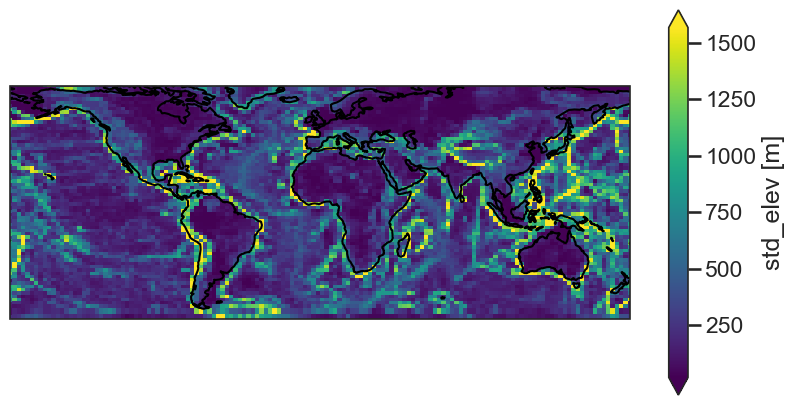

In [18]:
putils.plot_latlon_platecarree(ds.std_elev,time='',title='',cbar_label='std_elev [m]')

### Save all LGM iTraCE data at 200 yr resolution

The following cell loads all the iTraCE d18Ow (amount weighted) at 200 years of resolution, concatenates it into one dataframe and saves it locally (env. 850 Mo).

In [ ]:
import json
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)
list_itrace_df = []
for kyr,t_dict in itrace_sims.items():
    if kyr!='_comment':
        print('Loading data of ',kyr,' yr BP')
        kyr = int(float(kyr))
        # DATA
        # load d18O data 
        d18O_df = gutils.get_preprocessed_itrace_data(res=200,
                                                      true_kyr=kyr,
                                                      sim_kyr=t_dict['yrBPname'],
                                                      sim_num=t_dict['num'],
                                                      sim_suffix=t_dict['suffix'],
                                                      sim_prefix='b.e13.Bi1850C5.f19_g16',
                                                      sim_forcings=t_dict['forcings'],
                                                      sim_model='clm2.h0',
                                                      verbose=False) # type:ignore
        # keep only relevant columns
        d18O_subdf = d18O_df[['d18Op','lat','lon','time']].copy() #type:ignore
        d18O_subdf = d18O_subdf.drop_duplicates(subset=['lat','lon','time'])#type:ignore
        list_itrace_df.append(d18O_subdf)
    
itrace_df = pd.concat(list_itrace_df)

itrace_df.to_csv('/media/luluxette/T7_Shield/pdm/itrace_res200yr_d18Ow_20_11_kaBP.csv')

Loading data of  12  yr BP


## Modelling on aggregated variograms

##### Modelling on a 1000yr aggregated vario 

In [ ]:
# chen_variogram_df = pd.read_csv('../output/variograms/alltimes_multilinear_elev_lat_variogram_df_chen.csv').rename(columns={'bin_count':'count'})
itrace_variogram_df_all = pd.read_csv('../output/variograms/itrace/tests/vario_df.csv')
# itrace_variogram_df0 = pd.read_csv('../output/variograms/global_variogram_d0_df_itrace.csv')
# itrace_variogram_df45 = pd.read_csv('../output/variograms/global_variogram_d45_df_itrace.csv')
# itrace_variogram_df90 = pd.read_csv('../output/variograms/global_variogram_d90_df_itrace.csv')
# itrace_variogram_df135 = pd.read_csv('../output/variograms/global_variogram_d135_df_itrace.csv')

dict_dfs= {
            # 'c_all':{'df': chen_variogram_df},
           'i_all': {'df': itrace_variogram_df_all},
        #    'i_0': {'df': itrace_variogram_df0},
        #    'i_45': {'df': itrace_variogram_df45},
        #    'i_90': {'df': itrace_variogram_df90},
        #    'i_135': {'df': itrace_variogram_df135}
        }

In [ ]:
model_name = 'spherical'

for key in dict_dfs.keys():
    print(key)
    dict_dfs[key]['params'],dict_dfs[key]['fct_fitted'],dict_dfs[key]['pcov'] = gutils.fit_variogram_model(bin_edges=dict_dfs[key]['df']['lag'], # type:ignore
                                                                                gammas=dict_dfs[key]['df']['gamma'],
                                                                                model_name=model_name,
                                                                                pair_counts=dict_dfs[key]['df']['count'],
                                                                                bounds = ([0,0,0],[1e8,1e2,1e2])
                                                                                ) 

# params_itrace,fct_fitted_itrace,pcov_itrace = gutils.fit_variogram_model(bins=itrace_variogram_df_all['lag'],
#                                                                        gammas=itrace_variogram_df_all['gamma'],
#                                                                        model=model_name,
#                                                                        pair_counts=itrace_variogram_df_all['bin_count']
#                                                                        )

i_all


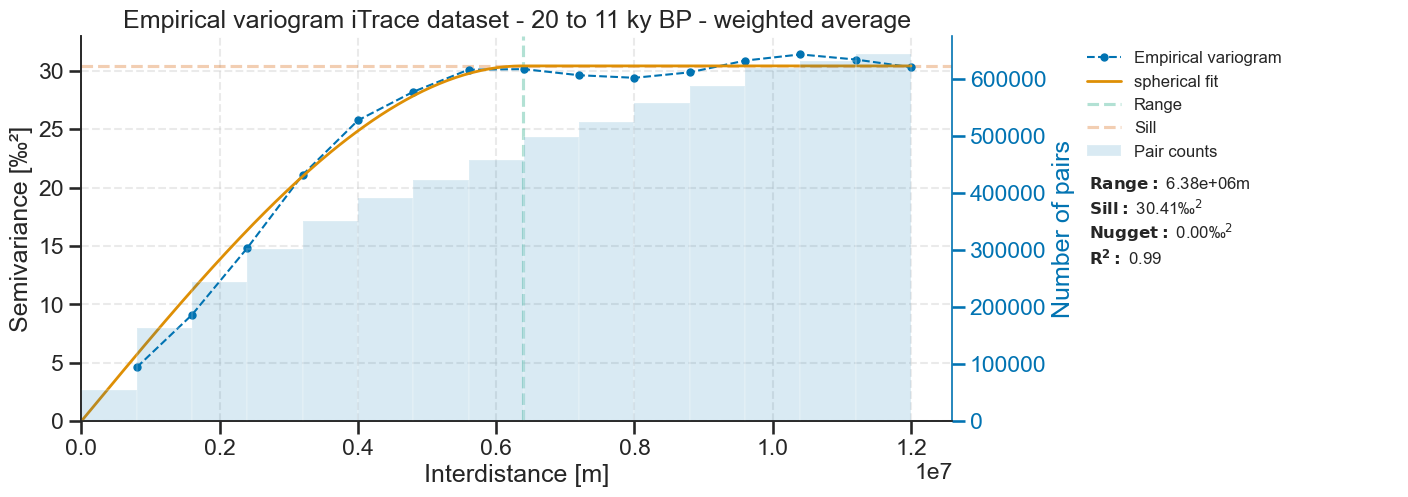

In [ ]:
fig,ax = putils.plot_variogram_from_bins_and_gamma(bin_edges=dict_dfs['i_all']['df']['lag'],
                                          gamma=dict_dfs['i_all']['df']['gamma'],
                                          title='iTrace dataset - 20 to 11 ky BP - weighted average',
                                          counts=itrace_variogram_df_all['count'],
                                          plot_model=True,
                                          model_name=model_name,
                                          model_fct=dict_dfs['i_all']['fct_fitted'],
                                          model_params=dict_dfs['i_all']['params'],
                                          figsize=(17,5),
                                          save_name='../output/variograms/itrace/tests/vario_fig.png'
                                          ) # type:ignore
plt.show()
plt.close('all')

# fig,ax = putils.plot_variogram_from_bins_and_gamma(centers=dict_dfs['c_all']['df']['lag'],
#                                           gamma=dict_dfs['c_all']['df']['gamma'],
#                                           time='Chen et al. dataset - 1870 to 2017 - weighted average',
#                                           counts=chen_variogram_df['count'],
#                                           min_pairs=20,
#                                           plot_model=True,
#                                           model_name=model_name,
#                                           model_fct=dict_dfs['c_all']['fct_fitted'],
#                                           model_params=dict_dfs['c_all']['params'],
#                                           figsize=(10,5),
#                                           save_name='../output/variograms/fig_alltimes_multilinear_elev_lat_variogram_model_chen.png'
#                                           ) #type:ignore
plt.show()
plt.close('all')

In [ ]:
# with open('../output/variograms/global_variogram_model_dict_chen.json', 'w') as fp:
#     json.dump(dict_dfs['c_all']['params'], fp)
# with open('../output/variograms/global_variogram_model_dict_itrace.json', 'w') as fp:
#     json.dump(dict_dfs['i_all']['params'], fp)

In [ ]:
list_dir = [0,45,90,135]
ranges=[]
fig,axes = plt.subplots(2,2,figsize=(20,10))
for i in range(2):
    for j in range(2):
        key = f'i_{list_dir[j+2*i]}'
        axes[i,j] = putils.plot_variogram_from_bins_and_gamma(bin_edges=dict_dfs[key]['df']['lag'],
                                                            gamma=dict_dfs[key]['df']['gamma'],
                                                            title='iTrace dataset - 11.7 to 11 ky BP - weighted average',
                                                            counts=dict_dfs[key]['df']['count'],
                                                            plot_model=True,
                                                            model_name=model_name,
                                                            model_fct=dict_dfs[key]['fct_fitted'],
                                                            model_params=dict_dfs[key]['params'],
                                                            figsize=(10,5),
                                                            ax_ = axes[i,j]
                                                            #     save_name='../output/variograms/fig_global_variogram_and_model_chen.png'
                                                            ) # type:ignore
        axes[i,j].set_title(f'dir={list_dir[j+2*i]}')
        if model_name !='composite':
            ranges.append(dict_dfs[key]['params']['range'])
        
plt.show()
plt.close('all')

for dir, r in zip(list_dir, ranges):
    print(f'Range in direction {dir}°: {r}')
anisotropy_ratio = max(ranges) / min(ranges)
print(f'Anisotropy Ratio: {anisotropy_ratio}')
max_range_index = ranges.index(max(ranges))
print(f'Anisotropy Direction: {list_dir[max_range_index]}°')

##### Aggregating variograms between 20-11 ka BP

In [ ]:
# collect all the variogram semivariances and gamma from the different time slices (direction None)
lags = None
all_gammas_list = []
all_bins_counts_list = []
with open(f'{utils.get_project_root()}/data/iTrace_simulations_dict.json', 'r') as f:
    itrace_sims = json.load(f)

for t in itrace_sims.keys():
    if t!='_comment':
        df = pd.read_csv(f'{utils.get_project_root()}/output/variograms/2026-02-24_sisal_vs_itrace/itrace/sim{t}kyrBP/res2400/maxlag10000000nlags15/trend_multiple_linear_lat_latquad_ele_D/sisal_mask_2000km/vario_None_df_all_iterations.csv')
        for s in np.unique(np.asarray(df.time_slice.values)): 
            if lags is None :
                lags = df.loc[df.time_slice==s,'lag'].values # type:ignore
            all_gammas_list.append(df.loc[df.time_slice==s,'gamma'].values)# type:ignore
            all_bins_counts_list.append(df.loc[df.time_slice==s,'count'].values)# type:ignore

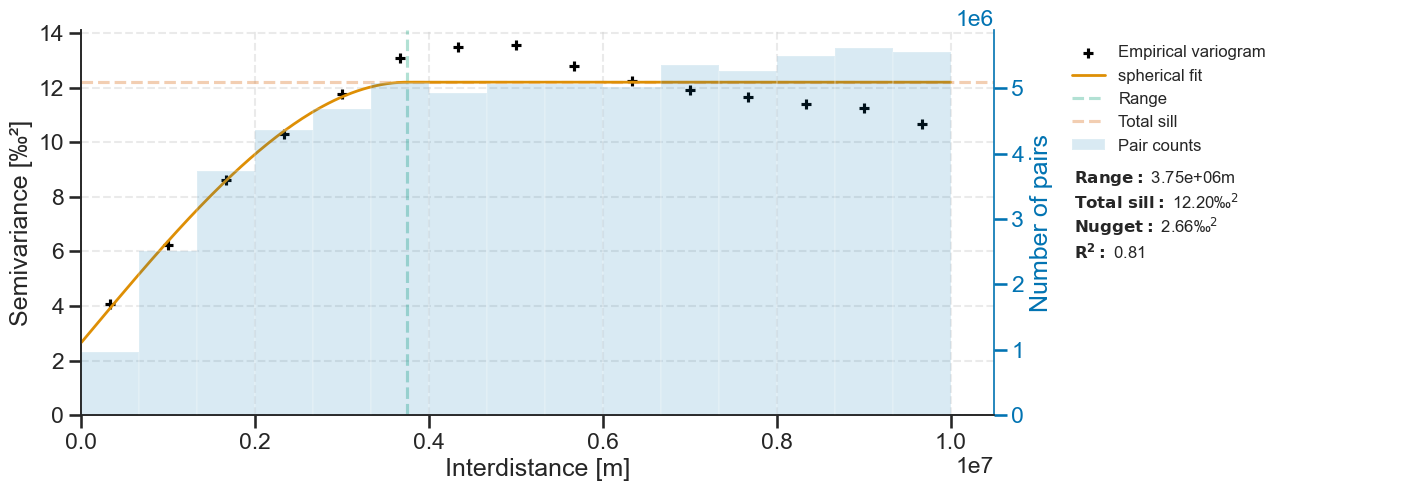

In [ ]:
df_all_agg = gutils.aggregate_variograms(bin_counts=all_bins_counts_list,gammas=all_gammas_list,bins=lags)
params, fct, _ = gutils.fit_variogram_model(
    bin_edges=lags,
    gammas=df_all_agg['gamma'], #type:ignore
    model_name='spherical',
    pair_counts=df_all_agg['count'], #type:ignore
    bounds = ([0,0,0],[1e8,1e2,1e2])
) 

# save the model for the KED 
with open(f'{utils.get_project_root()}/output/variograms/2026-02-24_sisal_vs_itrace/itrace/vario_res200y_maxlag10e6_nlags15_latlatquadeleD_mask2000.json', 'w') as filename:
            json.dump(params, filename)

fig,ax = putils.plot_variogram_from_bins_and_gamma(bin_edges=lags,# type:ignore
                                          gamma=df_all_agg['gamma'], #type:ignore
                                          title='',#, iTrace dataset - 20 to 11 ky BP - weighted average',
                                          counts=df_all_agg['count'], #type:ignore
                                          plot_model=True,
                                          model_name='spherical',
                                          model_fct=fct,
                                          model_params=params,
                                          figsize=(17,5),
                                          save_name='../output/results_figs/variogram_itrace_20_to_11_kaBP.png'
                                          ) # type:ignore
plt.show()
plt.close('all')


,lag,gamma,count
0,6.666487e+05,4.053212,957565
1,1.333297e+06,6.219385,2501600
2,1.999946e+06,8.631809,3731630
3,2.666595e+06,10.290268,4357665
4,3.333243e+06,11.757109,4674770
5,3.999892e+06,13.070671,5083790
6,4.666541e+06,13.501029,4920035
7,5.333190e+06,13.564084,5063115
8,5.999838e+06,12.783960,5066740
9,6.666487e+06,12.238517,5009495


## RCWIP data

RCWIP2 is a high resolution isoscape (30 arcseconds in all directions) covering all land areas on Earth, for the time period 1960-2016 (no time series, just the mean over this time range). It used model and GNIP data. 

> The dataset files are in geotif format, by region. Each region is defined as a rectangle covering 30 degrees of latitude and 30 degrees of longitude. Hence, we need some preprocessing to screen the data at itrace resolution and obtain one global dataframe for this dataset.

**Skip the section below if you do not want to see all details and directly load the preprocessed verion.**

#### preprocessing

In [ ]:
import rasterio 
from rasterio.transform import xy

itrace_df = gutils.get_preprocessed_itrace_data(data_folder='/media/luluxette/T7_Shield/pdm/iTrace/',res=12*1000,format='df',P=False)
itrace_df['lon_negpos'] = utils.convert_lon_0_360_to_neg180_180(itrace_df['lon'].values) # type: ignore
itrace_locs = itrace_df[['lat','lon','lon_negpos']].drop_duplicates() # type:ignore

loading itrace files
This dataset contains  12000  time steps.
   bins of width=12000 months (1000 years)
   converting xr to DataFrame (~2 minutes)
done


In [ ]:
# loop over all rcwip files and screen to itrace locations only...
# takes a while .... ~ 13 minutes
rcwip_df_list = []
for lon in [-180,-150,-120,-90,-60,-30,0,30,60,90,120,150]:
    if lon<0:
        lo = f'W{-lon}'
    else : 
        lo = f'E{lon}'

    for lat in [60,30,0,-30,-60]:
        if lat<0:
            la = f'S{-lat}'
        else : 
            la = f'N{lat}'
        
        print('=============',lo,la,'===============')
        itrace_sublocs = itrace_locs[itrace_locs['lat'].between(lat,lat+30.0) & itrace_locs['lon_negpos'].between(lon,lon+30.0)].copy()
        if len(itrace_sublocs)==0:
            print('no itrace data in this area')
            continue
        
        try :
            with rasterio.open(f'../data/modern/RCWIP2_isoscape/O18_{lo}_{la}_13.tif') as f:
                rcwip_data = f.read(1)
                transform = f.transform
                crs = f.crs
                nodata= f.nodata
        except Exception as e :
            print(e)
            continue

        # compute coordinates 
        rows, cols = np.meshgrid(
            np.arange(rcwip_data.shape[0]),
            np.arange(rcwip_data.shape[1]),
            indexing="ij"
        )
        xs, ys = xy(transform, rows, cols, offset="center")
        xs = np.array(xs)
        ys = np.array(ys)

        # get valid pixels
        values = rcwip_data.ravel()
        mask = np.ones(values.shape, dtype=bool)
        mask &= np.abs(values)<10e3
        mask &= ~np.isnan(values)

        # convert to dataframe
        rcwip_df = pd.DataFrame({
            "lon": xs[mask],
            "lat": ys[mask],
            "value": values[mask]
        })

        rcwip_data=[]
        rad = 50
        latlon_uniques = [] # keep track of which locs are already in final df to avoid duplicates
        for i,row in tqdm(itrace_sublocs.iterrows(),total=len(itrace_sublocs)): # tqdm(itrace_sublocs.iterrows(),total=len(itrace_sublocs)) :
                
                lat_ = row['lat']
                lon_ = row['lon_negpos']

                rcwip_df['dlat']=np.abs(rcwip_df['lat']-lat_)
                rcwip_df['dlon']=np.abs(rcwip_df['lon']-lon_)
                min_lon = rcwip_df.loc[rcwip_df['dlon'].idxmin(),'lon']
                min_lat = rcwip_df.loc[rcwip_df['dlat'].idxmin(),'lat']
                closest_rcwip = rcwip_df[(np.abs(rcwip_df['lat']-min_lat)<0.01)&(np.abs(rcwip_df['lon']-min_lon)<0.01)] # type:ignore
                
                if len(closest_rcwip)==0: # in case the optimal grid point is not valid (removed earlier from rcwip data)
                    eps=0.5
                    i=0.5
                    rcwip_subdf = pd.DataFrame()
                    while (len(rcwip_subdf)<1)&(eps<3):
                        eps += i
                        rcwip_subdf = rcwip_df[rcwip_df['lon'].between(lon_-eps,lon_+eps)
                                            & rcwip_df['lat'].between(lat_-eps,lat_+eps)].copy().reset_index()
                        if len(rcwip_subdf)<1: 
                            pass
                        else :
                            rcwip_subdf['dist_km'] = rcwip_subdf.apply(lambda row : utils.haversine((lat_,lon_),(row.lat,row.lon)), axis=1)
                            candidate = rcwip_subdf.loc[rcwip_subdf['dist_km'].idxmin(),['lat','lon','value','dist_km','dlon','dlat']] # type:ignore
                            if (candidate['dist_km']>rad).all():
                                pass
                            else :
                                closest_rcwip = pd.DataFrame({'lon':[candidate.lon],
                                                              'lat':[candidate.lat],
                                                              'value': [candidate.value],
                                                              'dist_km': [candidate['dist_km']]})
                if len(closest_rcwip)>=1 :
                    tuple_lonlat = (closest_rcwip['lat'].values[0],closest_rcwip['lon'].values[0])
                    if not tuple_lonlat in latlon_uniques :
                        rcwip_data.append({'d18Op':closest_rcwip['value'].values[0],
                                        'lat':closest_rcwip['lat'].values[0],
                                        'lon':closest_rcwip['lon'].values[0],
                                        }) 
                        latlon_uniques.append(tuple_lonlat)  
                    
        rcwip_df_list.append(pd.DataFrame(rcwip_data))

rcwip_final_df = pd.concat(rcwip_df_list)

============= W180 N60 ===============


100%|██████████| 65/65 [00:05<00:00, 11.02it/s]


============= W180 N30 ===============


100%|██████████| 21/21 [00:01<00:00, 13.09it/s]


============= W180 N0 ===============


...

100%|██████████| 24/24 [00:02<00:00,  9.83it/s]


============= E150 N0 ===============
no itrace data in this area
============= E150 S30 ===============


100%|██████████| 19/19 [00:00<00:00, 19.01it/s]


============= E150 S60 ===============


100%|██████████| 21/21 [00:02<00:00,  8.46it/s]


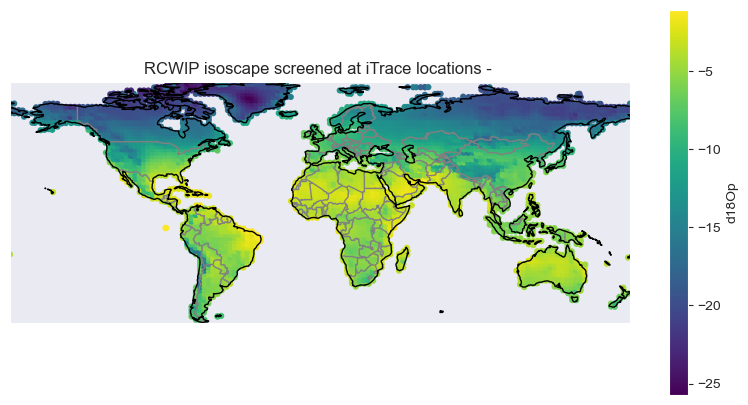

In [ ]:
fix,ax = putils.plot_latlon_platecarree_df(rcwip_final_df,title='RCWIP isoscape screened at iTrace locations',countries_borders = True)

In [ ]:
rcwip_final_df.to_csv('../data/modern/RCWIP2_isoscape/rcwip2_screened_itrace.csv')

#### conputations on preprocessed RCWIP

In [ ]:
rcwip_final_df = pd.read_csv('../data/modern/RCWIP2_isoscape/rcwip2_screened_itrace.csv')

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:10<00:00, 10.72s/it]


{'nugget': np.float64(0.10000000000000002), 'range1': np.float64(7335899.804073539), 'sill1': np.float64(2.7157844369407083), 'range2': np.float64(3255240.4498964082), 'sill2': np.float64(4.110777163471374), 'model_name': 'spherical+gaussian'}


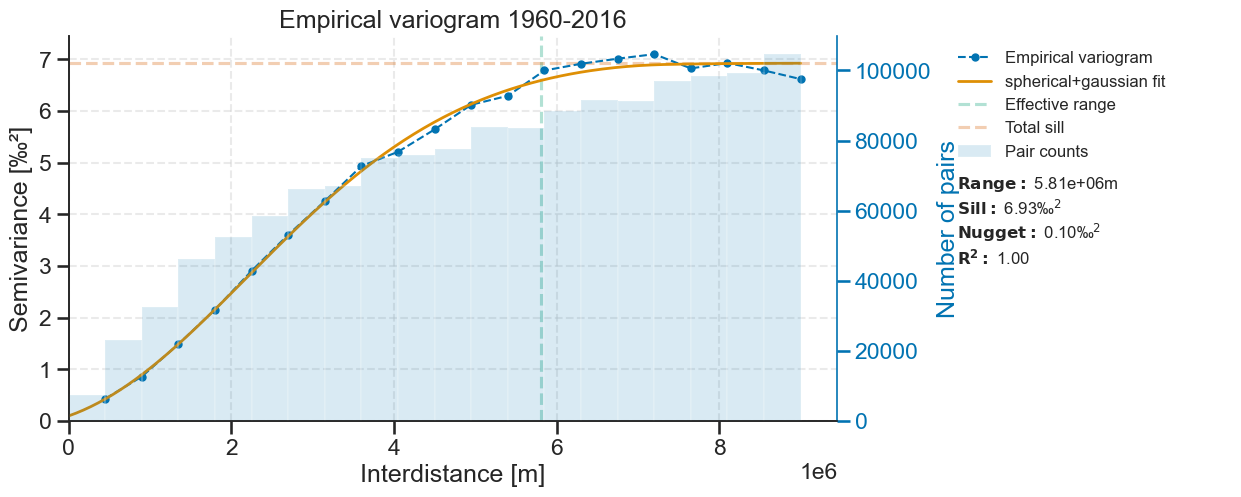

In [ ]:
# detrend and compute variogram 
rcwip_final_df['time']=0.0 # rcwip has just one time step, that we set arbitrarily to 0 
bin_counts, gammas, bins, trend_results = gutils.iterative_variogram_computations(
    rcwip_final_df,
    trend='multiple_linear_latabs_latReLU_ele_D',
    verbose=False,
    maxlag=9e6)

bin_counts = np.sum(np.vstack(bin_counts),axis=0)

# fit model 
model= 'spherical+gaussian'
params, fitted_fct, _ =  gutils.fit_variogram_model(
    bins,gammas[0],
    model_name=model, 
    bounds=([0.1,0,0,0,0],[1e2,1e12,1e2,1e12,1e2]),
    weights_power=0.5,
    pair_counts = bin_counts,
    weighting='lags') # bounds of params 'nugget','range1','sill1','range2','sill2'
# plot
print(params)
fig,ax = putils.plot_variogram_from_bins_and_gamma(
    bins,
    gammas[0],
    title='1960-2016',
    counts= bin_counts,
    plot_model=True,
    model_name=model,
    model_params=params,
    model_fct= fitted_fct) # type:ignore
plt.show()